<a href="https://colab.research.google.com/github/teehere/Diabetes-Prediction-Using-Machine-Learning/blob/main/diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install missingno

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler

# **1. Load Data & Initial Checks**

In [ ]:
df = pd.read_csv('diabetes1.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35,0.0,33.6,0.627,50.0,1
1,1,85.0,66.0,29,0.0,26.6,0.351,31.0,0
2,8,183.0,64.0,0,0.0,23.3,0.672,32.0,1
3,1,89.0,66.0,23,94.0,28.1,0.167,21.0,0
4,0,137.0,40.0,35,168.0,43.1,2.288,33.0,1


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 771 entries, 0 to 770
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               771 non-null    int64  
 1   Glucose                   770 non-null    float64
 2   BloodPressure             770 non-null    float64
 3   SkinThickness             771 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       771 non-null    float64
 6   DiabetesPedigreeFunction  771 non-null    float64
 7   Age                       770 non-null    float64
 8   Outcome                   771 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.3 KB
None


In [ ]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 5


In [ ]:
# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

duplicates = df.duplicated().sum()
print(f"Number of duplicates after removed: {duplicates}")
print('Shape after dropping duplicates:', df.shape)

Number of duplicates after removed: 0
Shape after dropping duplicates: (766, 9)


In [ ]:
print("Missing values (before cleaning):\n",df.isnull().sum())

Missing values (before cleaning):
 Pregnancies                 0
Glucose                     1
BloodPressure               1
SkinThickness               0
Insulin                     3
BMI                         0
DiabetesPedigreeFunction    0
Age                         1
Outcome                     0
dtype: int64


# **2. Missing Value Analysis**

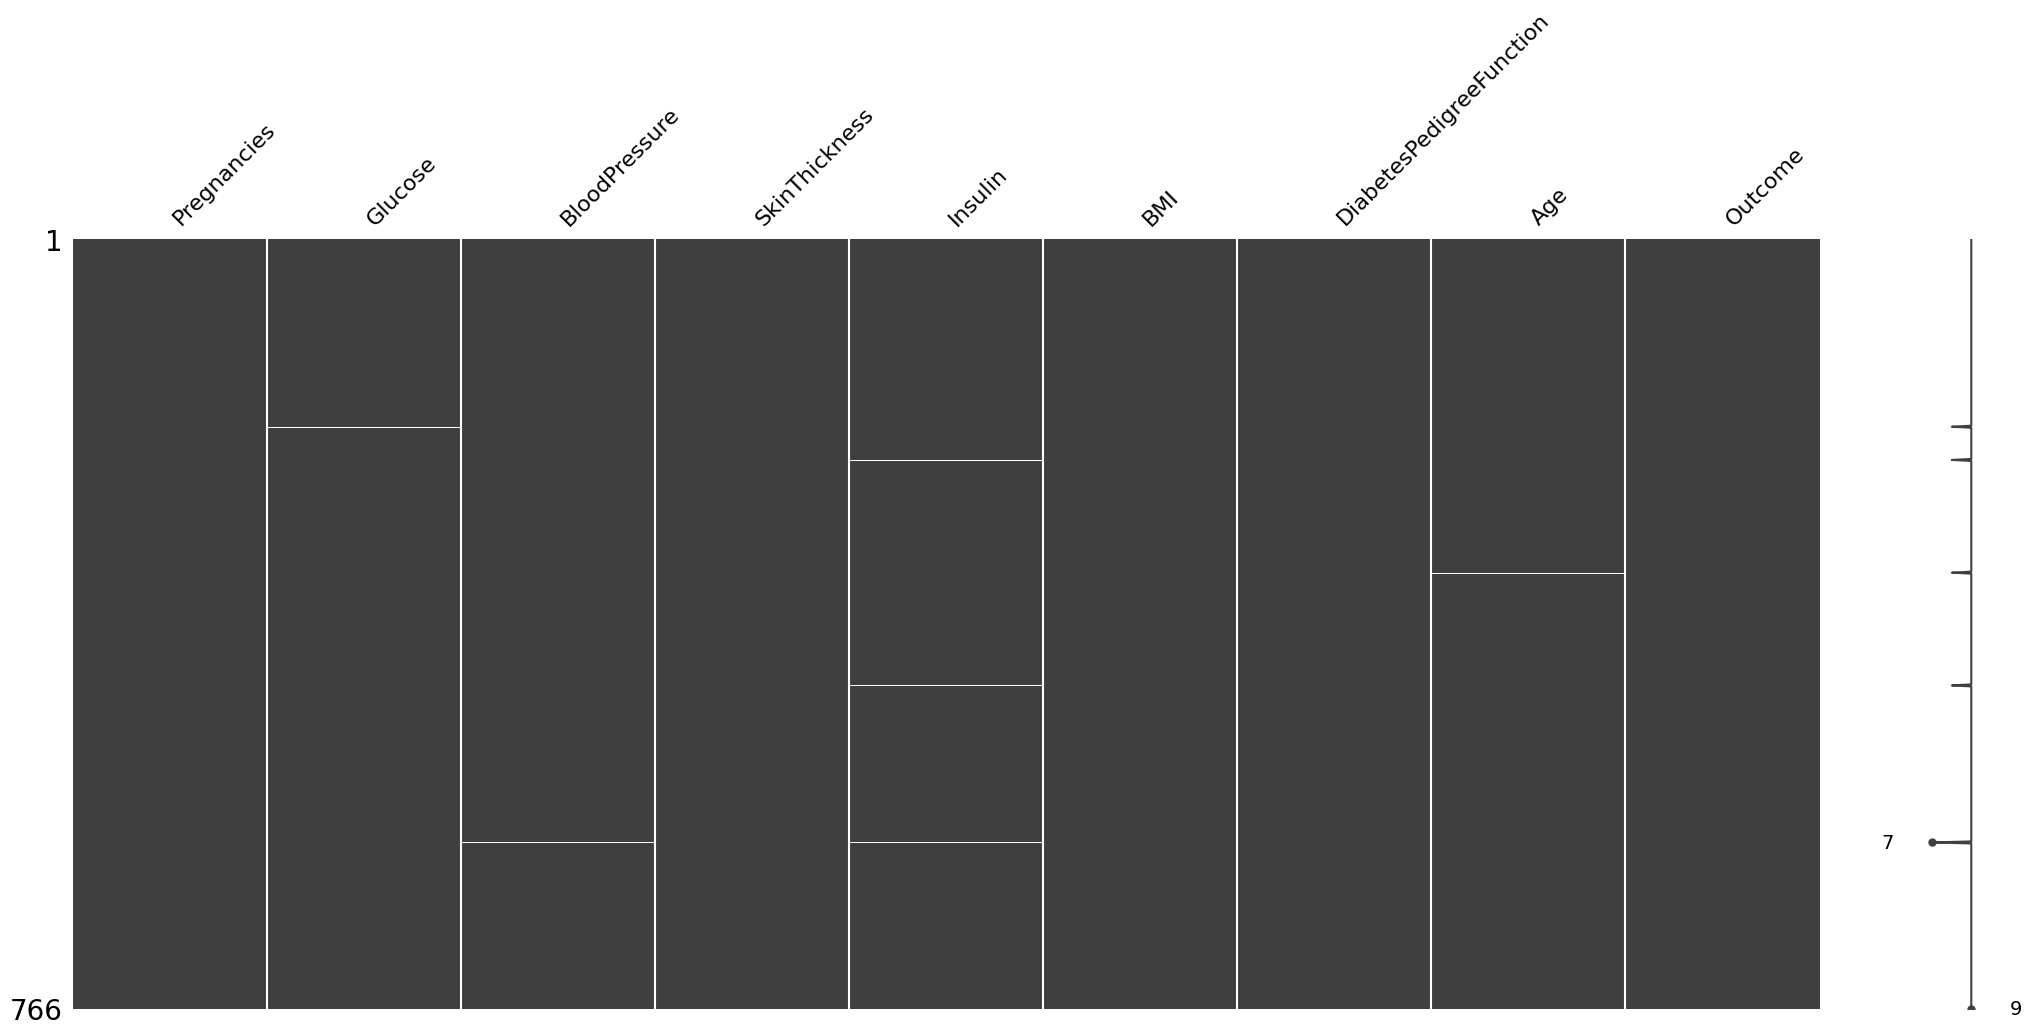

In [ ]:
msno.matrix(df)
plt.show()

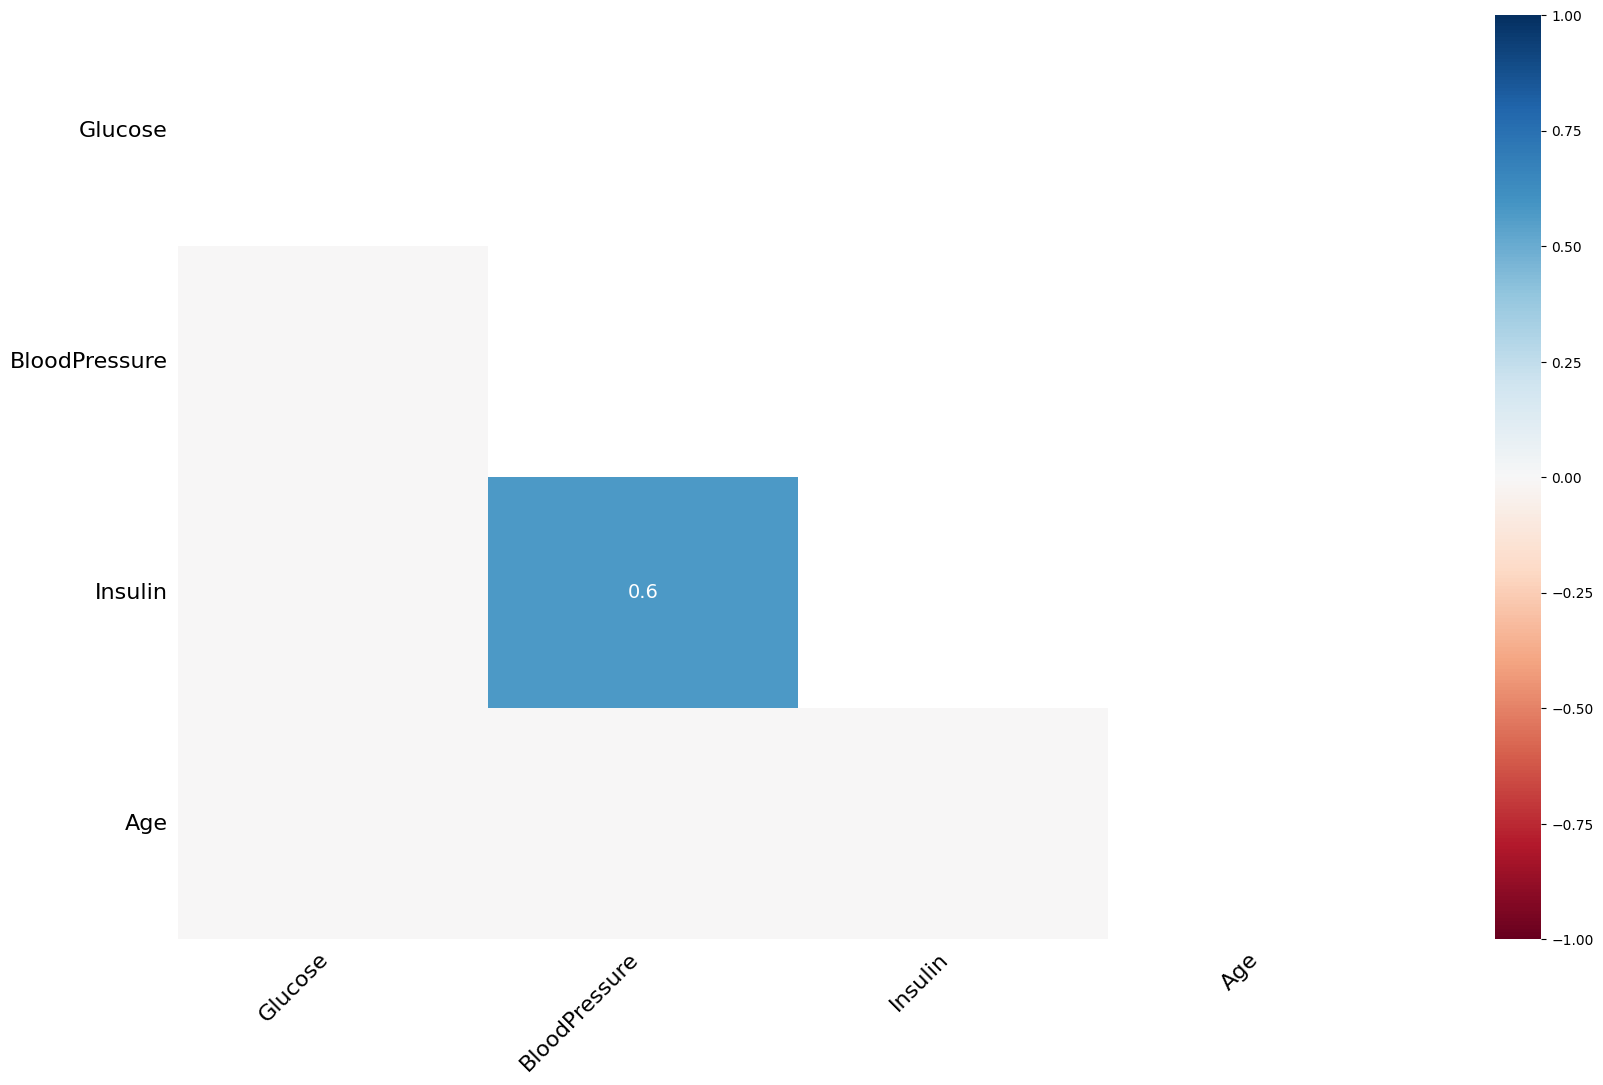

In [ ]:
msno.heatmap(df)
plt.show()

In [ ]:
# Identify fake missing values (zeros in certain columns)
cols_with_fake_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_fake_missing:
    num_zeros = (df[col] == 0).sum()
    print(f"{col} has {num_zeros} zeros ({num_zeros/len(df)*100:.1f}% of data)")

Glucose has 5 zeros (0.7% of data)
BloodPressure has 36 zeros (4.7% of data)
SkinThickness has 227 zeros (29.6% of data)
Insulin has 375 zeros (49.0% of data)
BMI has 11 zeros (1.4% of data)


In [ ]:
# Replace zeros with NaN
df_clean = df.copy()
for col in cols_with_fake_missing:
    df_clean[col] = df_clean[col].replace(0, np.nan)

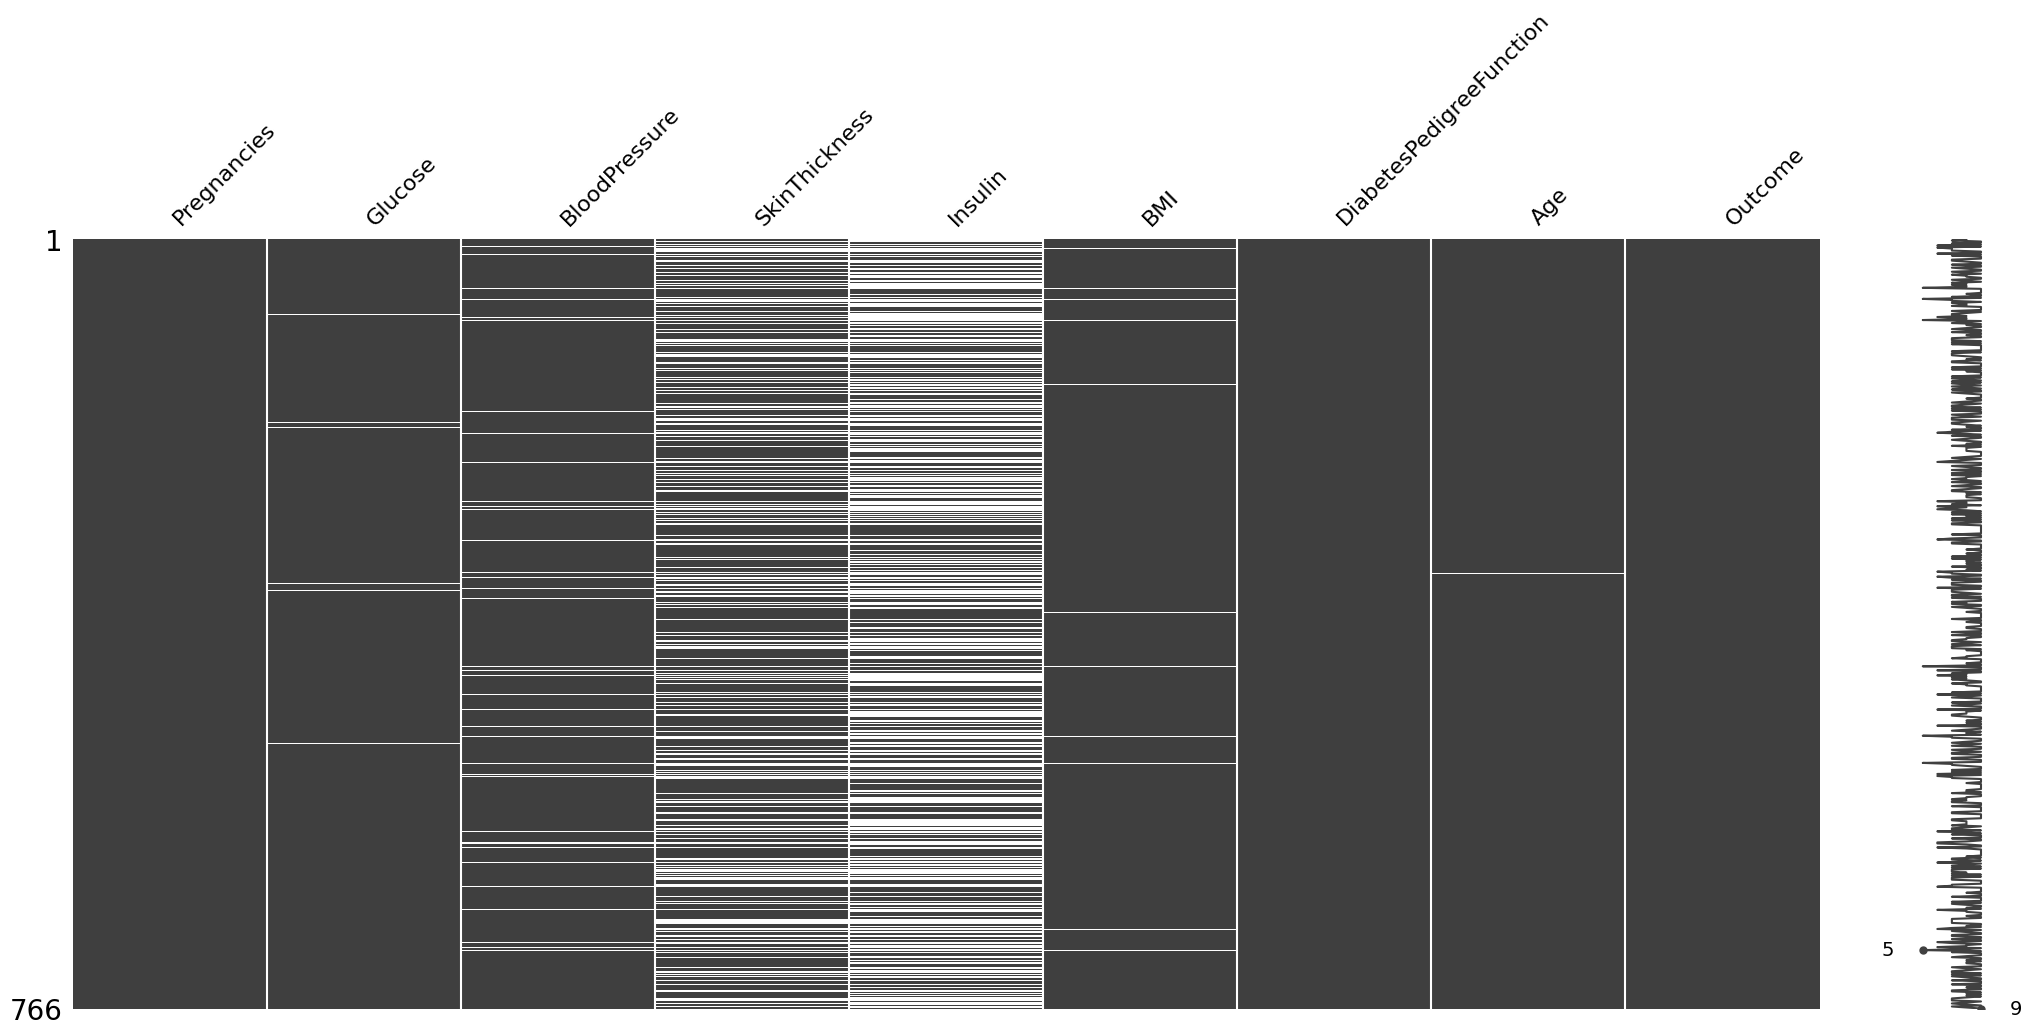

In [ ]:
# Visualize missing data after replacement
msno.matrix(df_clean)
plt.show()

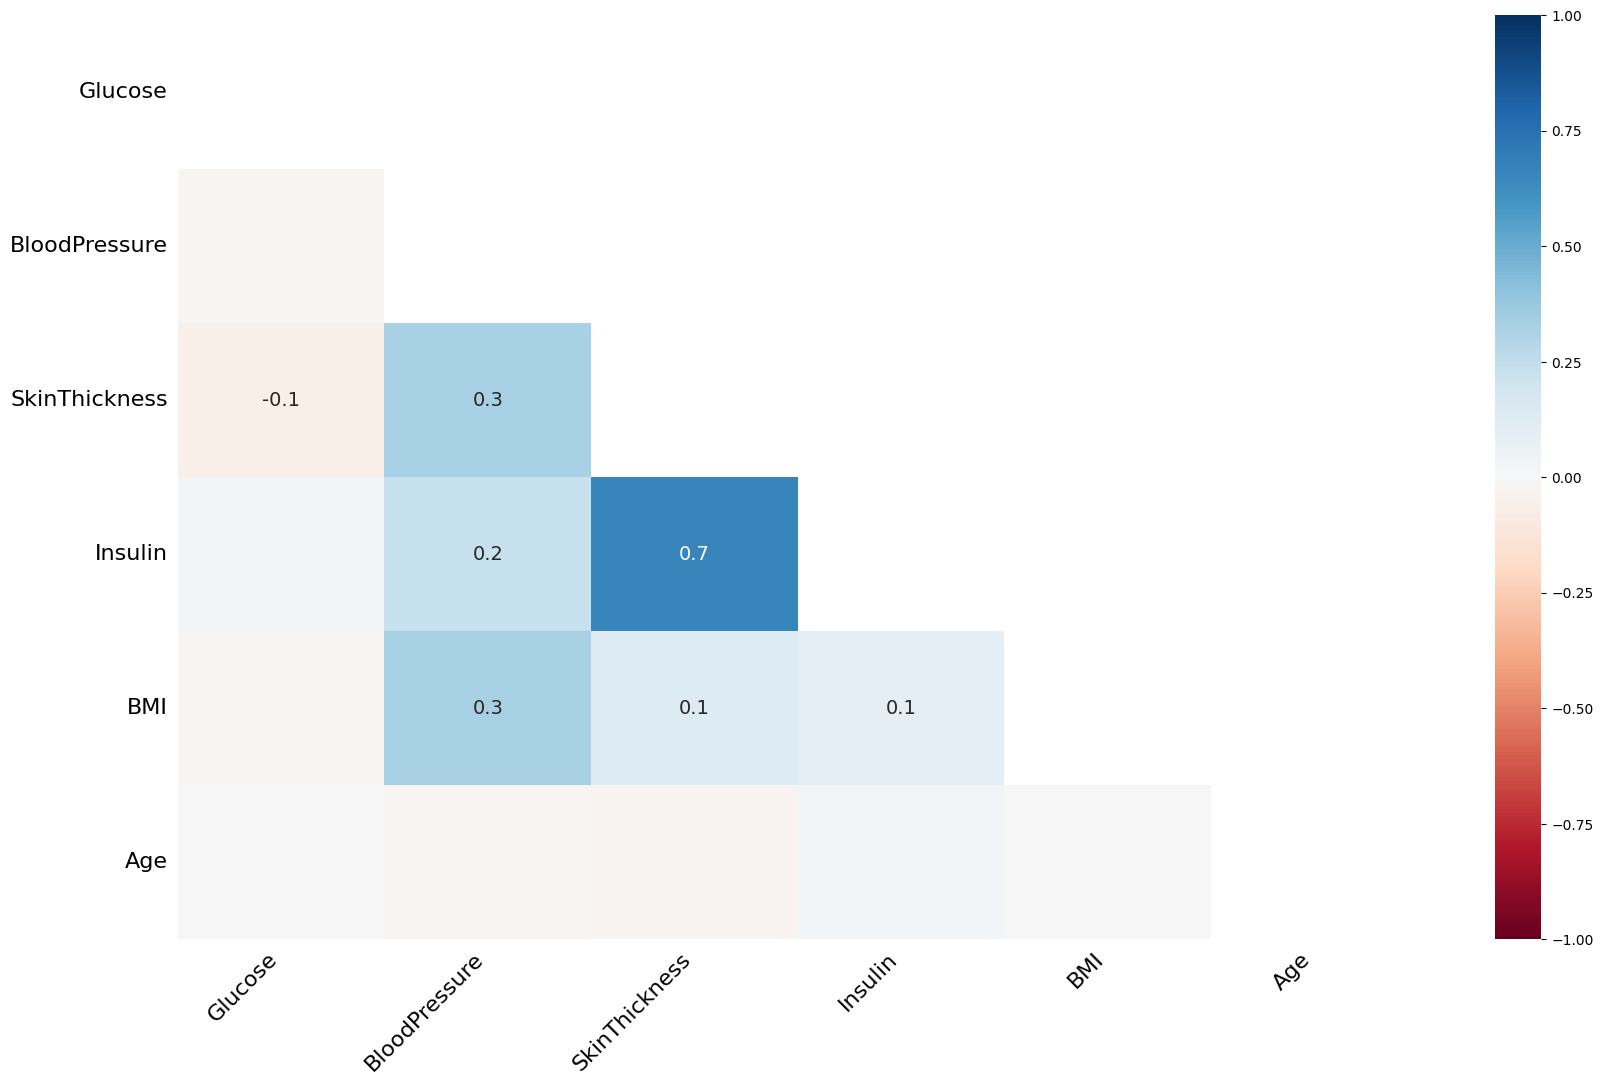

In [ ]:
msno.heatmap(df_clean)
plt.show()

In [ ]:
print("Missing values after cleaning:\n", df_clean.isnull().sum())

Missing values after cleaning:
 Pregnancies                   0
Glucose                       6
BloodPressure                37
SkinThickness               227
Insulin                     378
BMI                          11
DiabetesPedigreeFunction      0
Age                           1
Outcome                       0
dtype: int64


# **3. Split into 60% Train, 20% Val, 20% Test**

In [ ]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

In [ ]:
# Split off the 20% test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# Split the remaining 80% into 60% train, 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

In [ ]:
print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (459, 8)
Val shape: (153, 8)
Test shape: (154, 8)


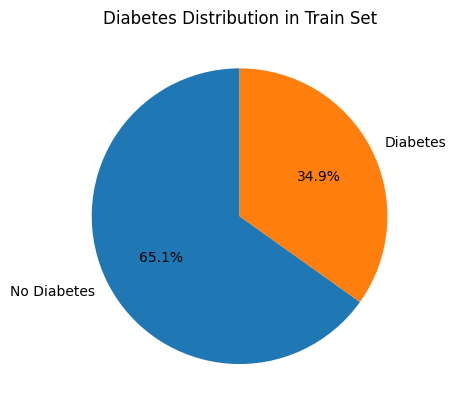

In [ ]:
# Pie chart
labels = ['No Diabetes', 'Diabetes']
plt.pie(y_train.value_counts(), labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Diabetes Distribution in Train Set')
plt.show()

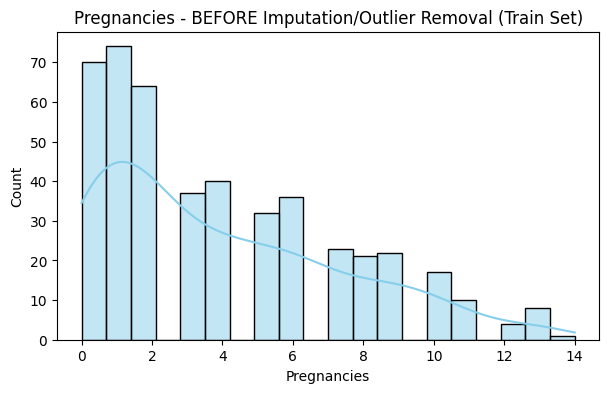

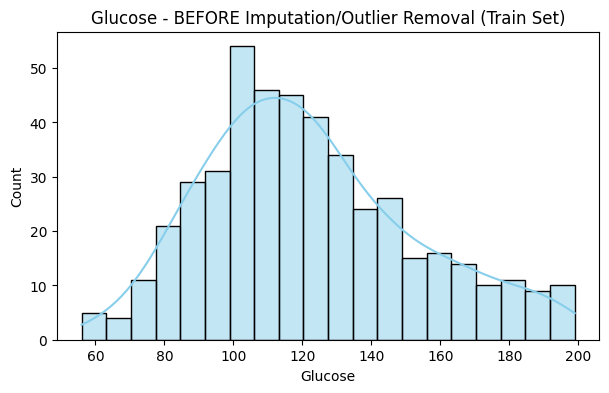

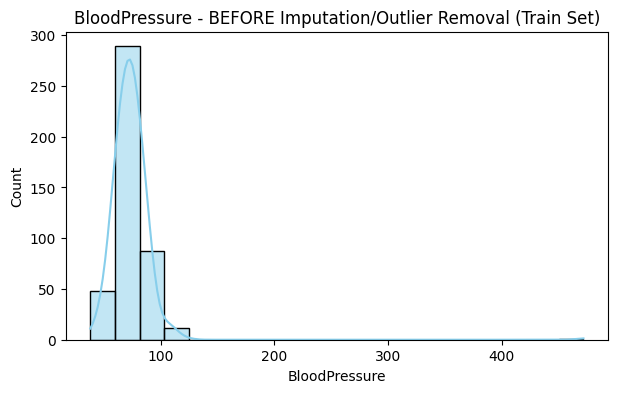

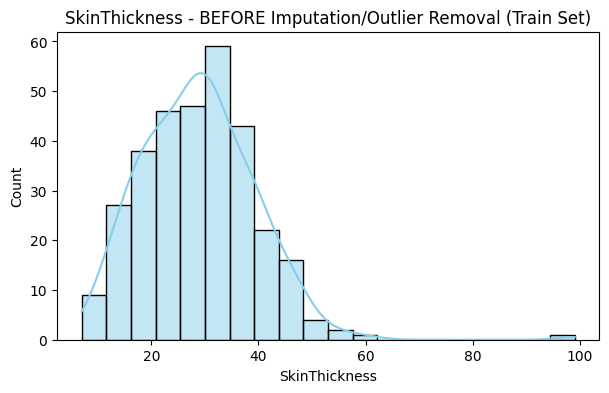

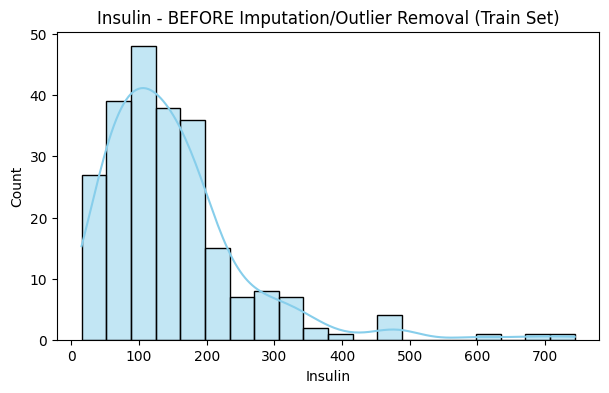

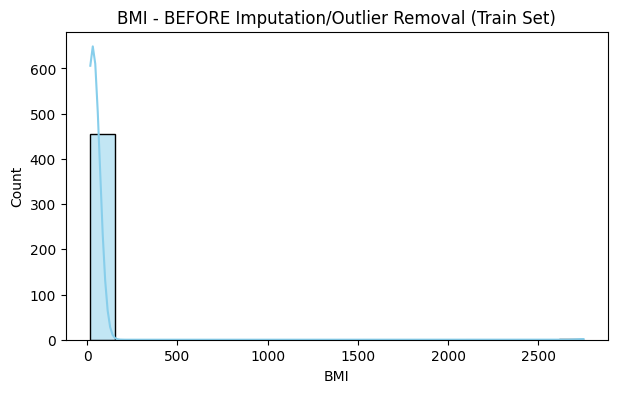

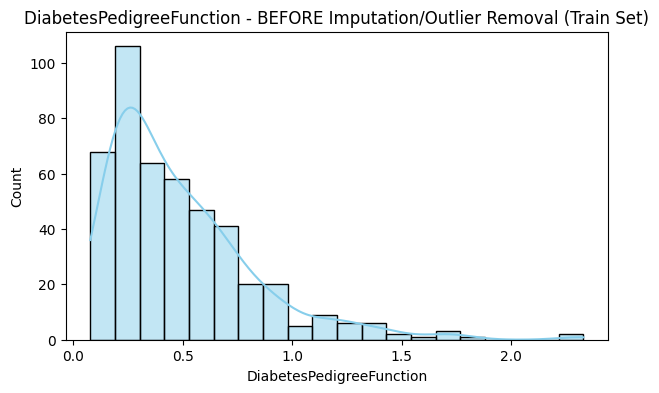

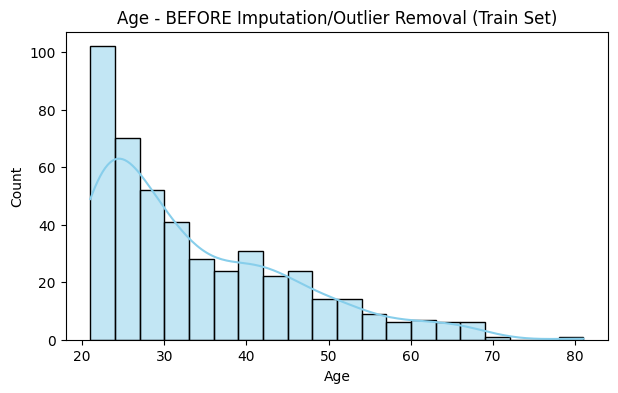

In [ ]:
# Distribution plots (histograms & KDE)
def plot_hist_kde(df, title):
    cols = df.columns
    for col in cols:
        plt.figure(figsize=(7, 4))
        sns.histplot(df[col].dropna(), bins=20, kde=True, color='skyblue')
        plt.title(f'{col} - {title}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()

# Usage example (before impute/outlier removal):
X_train_df = X_train.copy()
plot_hist_kde(X_train_df, 'BEFORE Imputation/Outlier Removal (Train Set)')

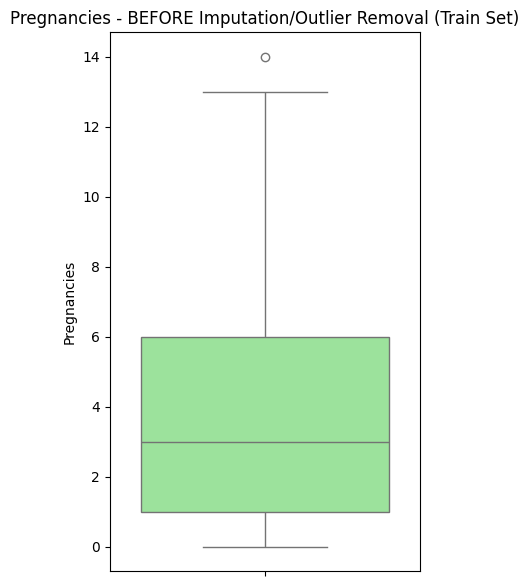

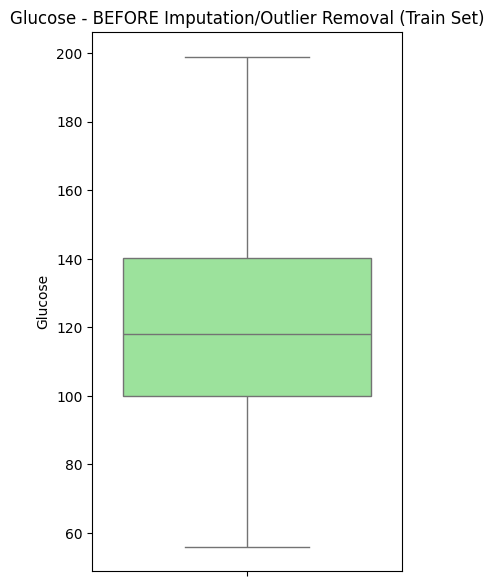

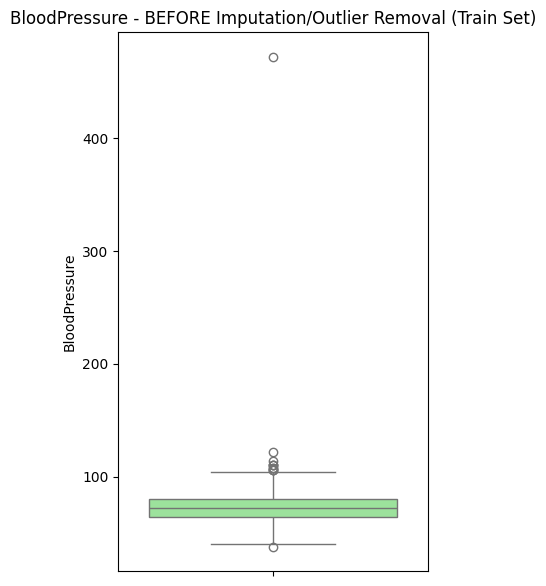

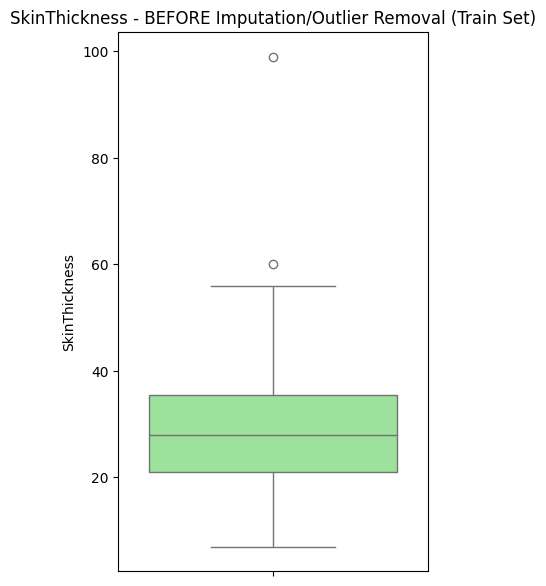

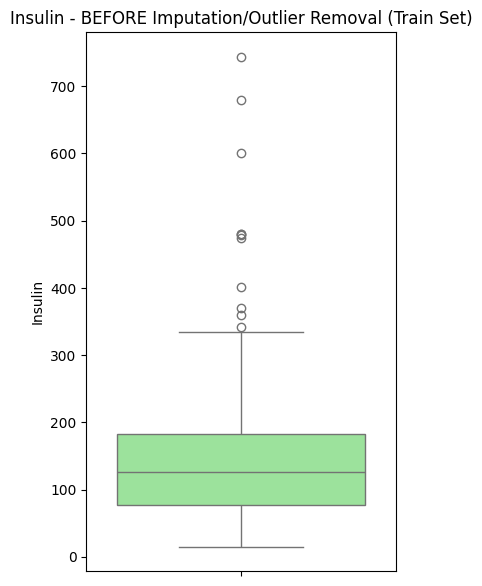

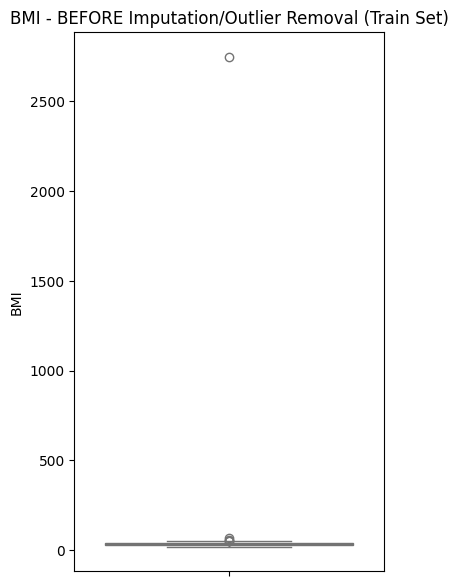

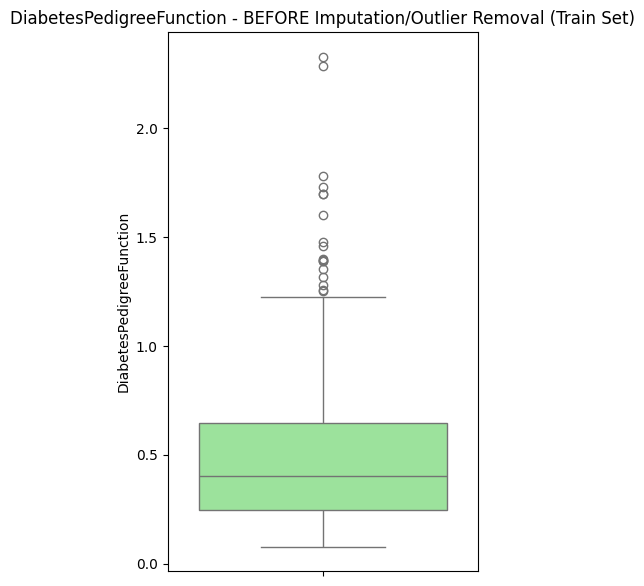

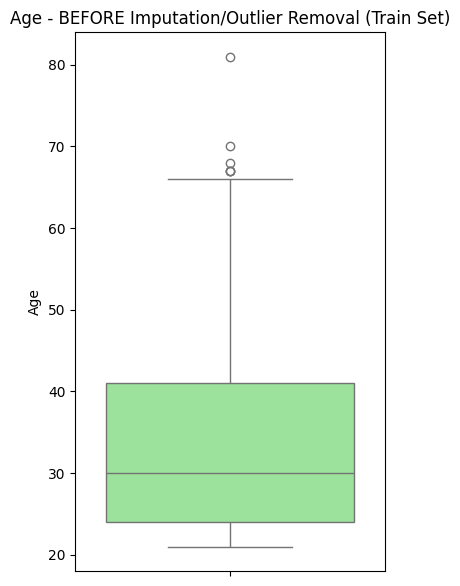

In [ ]:
# Boxplots
def plot_individual_boxplots(df, title):
    cols = df.columns
    for col in cols:
        plt.figure(figsize=(4, 7))
        sns.boxplot(y=df[col], color='lightgreen')
        plt.title(f'{col} - {title}')
        plt.ylabel(col)
        plt.show()

# Usage example (before impute/outlier removal):
plot_individual_boxplots(X_train, 'BEFORE Imputation/Outlier Removal (Train Set)')

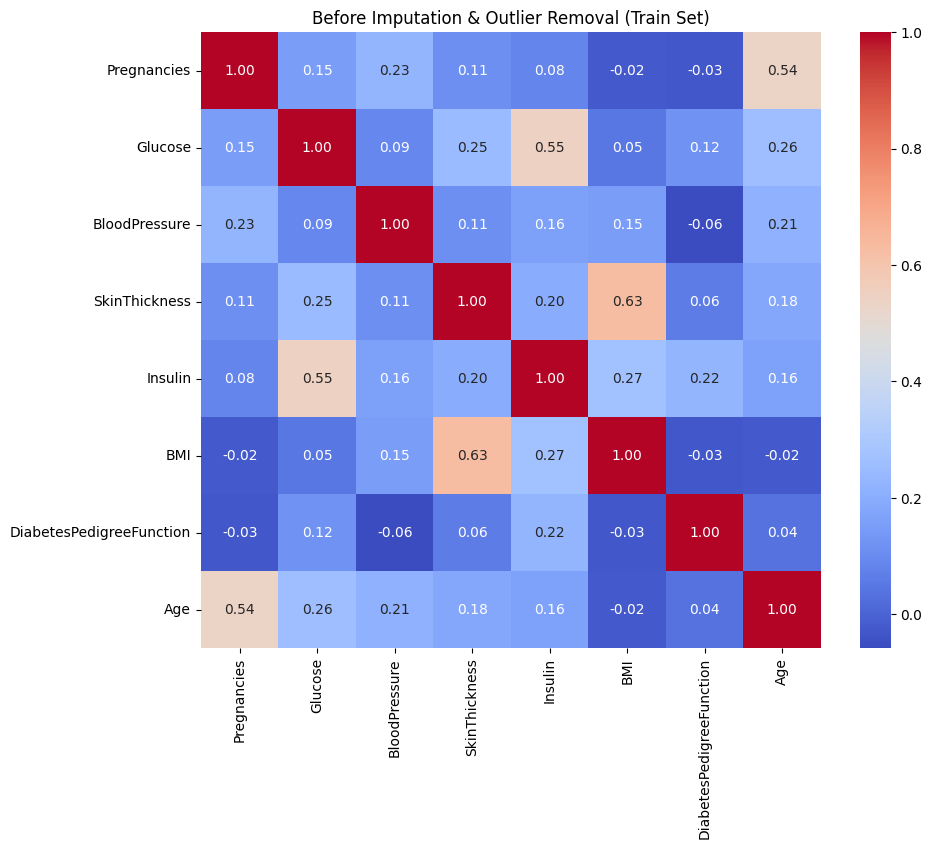

In [ ]:
# Correlation Metrix
plt.figure(figsize=(10,8))
corr_before = X_train.corr()
sns.heatmap(corr_before, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Before Imputation & Outlier Removal (Train Set)')
plt.show()

# **4. Imputation (Fill Missing Values)**

In [ ]:
# Initialize KNN imputer
imputer = KNNImputer(n_neighbors=5)

# Fit on training, transform all sets
X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)
X_test_imputed = imputer.transform(X_test)

In [ ]:
# Convert back to DataFrame
X_train_imputed_df = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_val_imputed_df = pd.DataFrame(X_val_imputed, columns=X_val.columns)
X_test_imputed_df = pd.DataFrame(X_test_imputed, columns=X_test.columns)

In [ ]:
# Check any remaining missing values
print('Missing after imputation (train):\n', X_train_imputed_df.isnull().sum().sum())
print('Missing after imputation (val):\n', X_val_imputed_df.isnull().sum().sum())
print('Missing after imputation (test):\n', X_test_imputed_df.isnull().sum().sum())

Missing after imputation (train):
 0
Missing after imputation (val):
 0
Missing after imputation (test):
 0


# **5. Outlier Detection**

In [ ]:
# Outlier Detection - Z-score method
z_scores = np.abs(zscore(X_train_imputed_df, nan_policy='omit'))
z_mask = (z_scores < 3).all(axis=1)  # True if all features < 3 stddev

X_train_no_outliers_z = X_train_imputed_df[z_mask].reset_index(drop=True)
y_train_no_outliers_z = y_train.reset_index(drop=True)[z_mask].reset_index(drop=True)

print("Shape after Z-score outlier removal:", X_train_no_outliers_z.shape)

Shape after Z-score outlier removal: (440, 8)


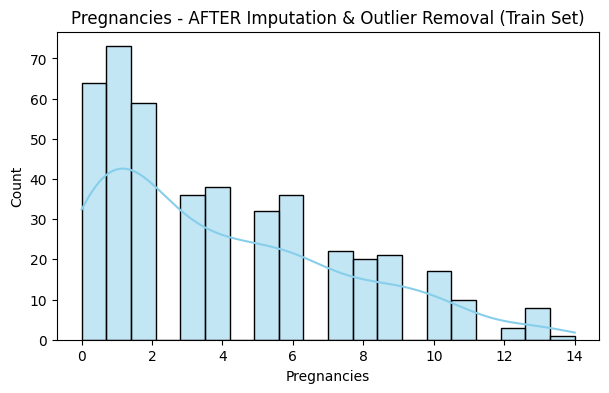

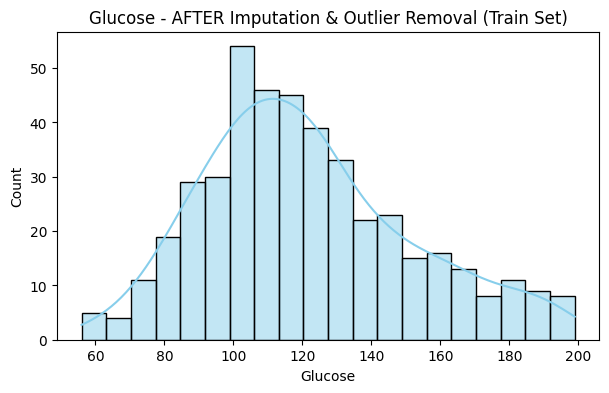

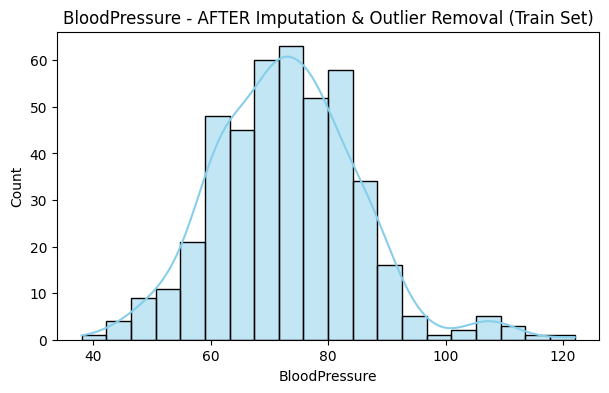

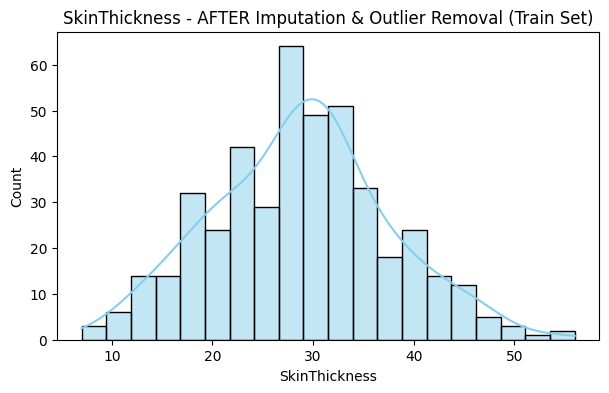

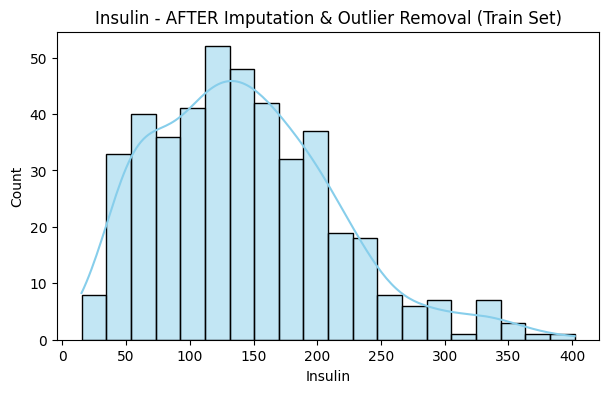

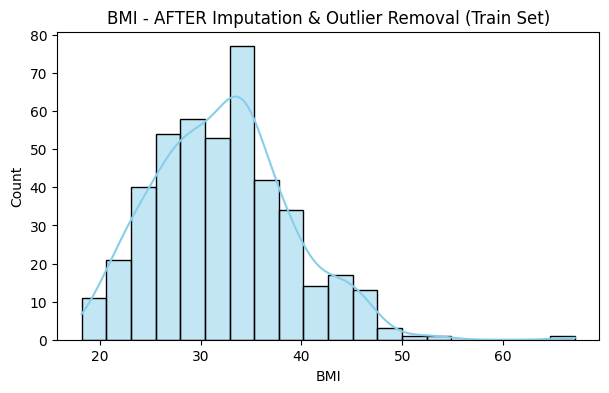

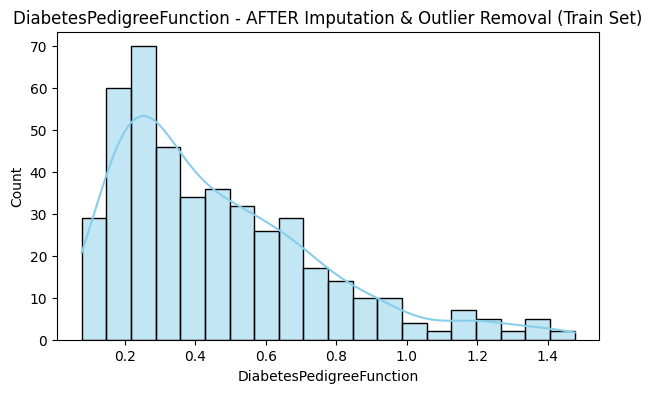

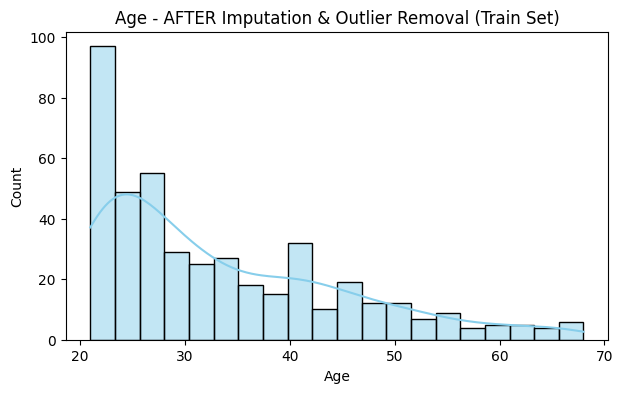

In [ ]:
# Plot histograms + KDE
plot_hist_kde(X_train_no_outliers_z, 'AFTER Imputation & Outlier Removal (Train Set)')

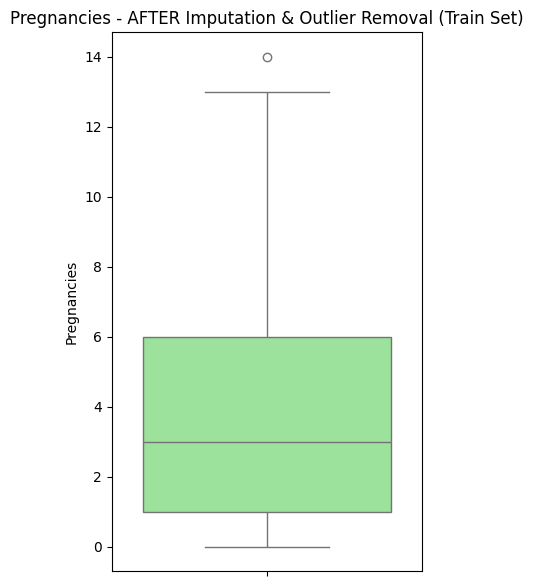

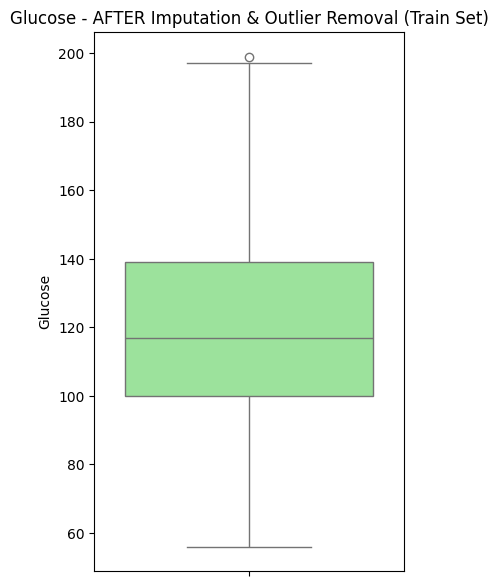

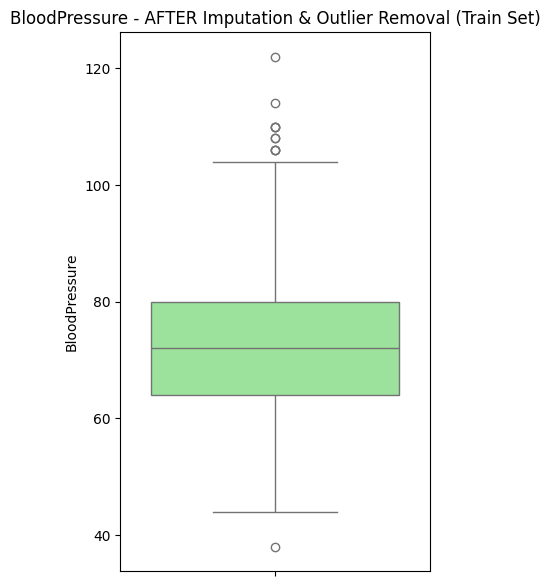

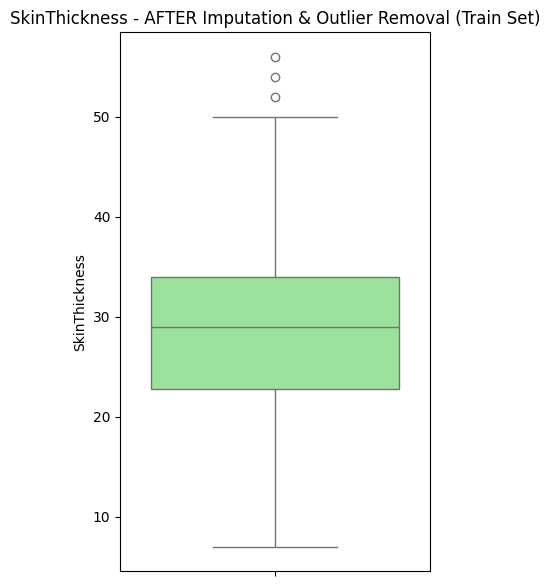

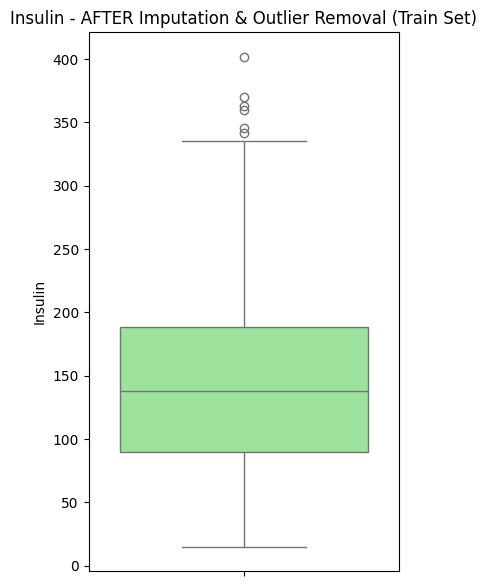

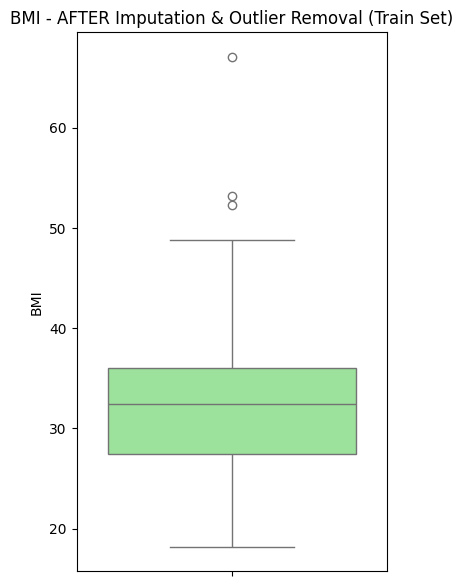

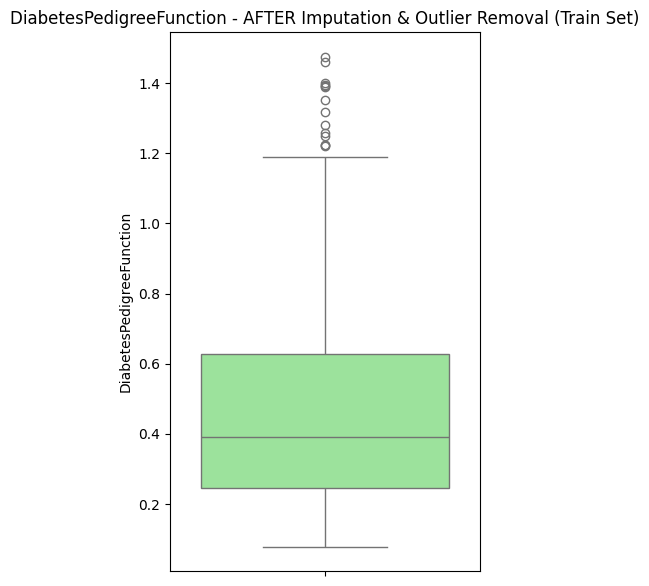

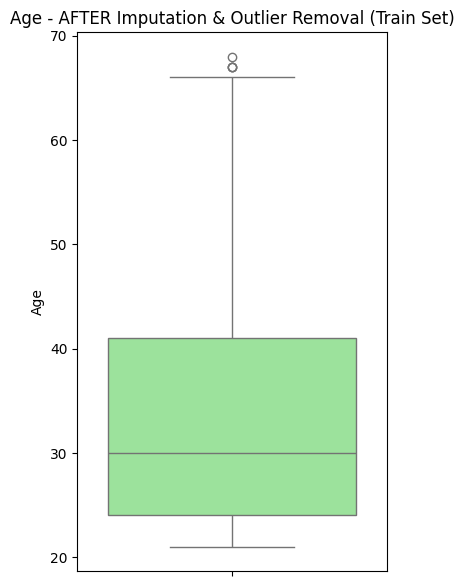

In [ ]:
# Plot individual boxplots
plot_individual_boxplots(X_train_no_outliers_z, 'AFTER Imputation & Outlier Removal (Train Set)')

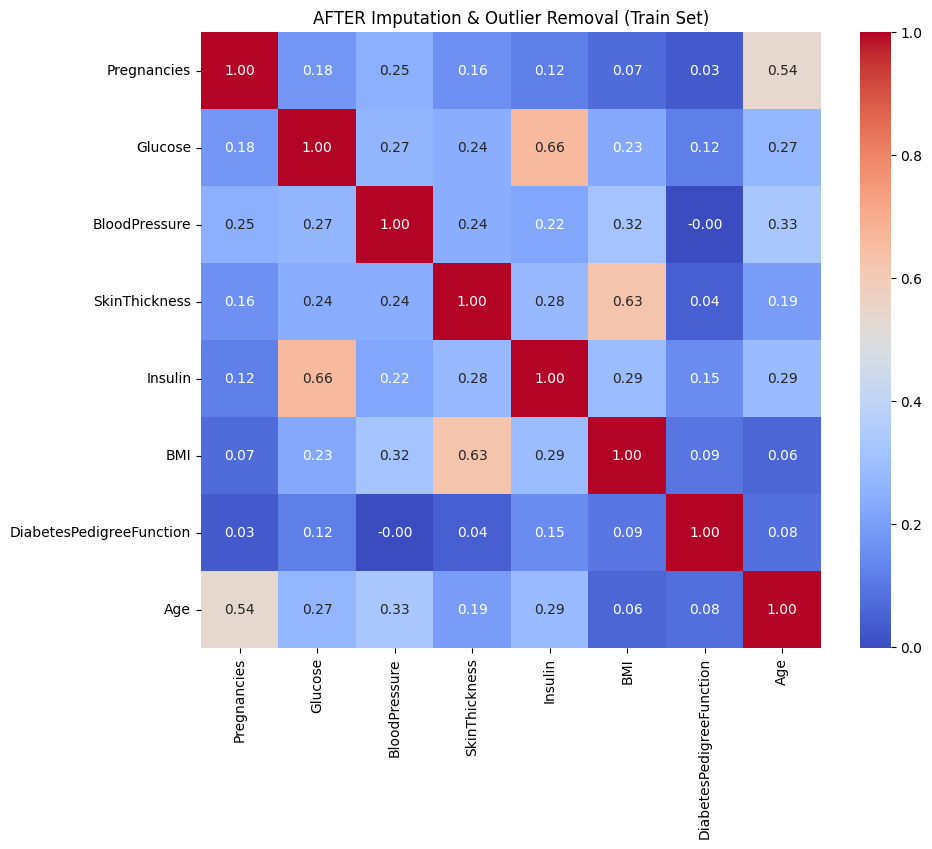

In [ ]:
# Correlation Metrix
plt.figure(figsize=(10,8))
corr = X_train_no_outliers_z.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('AFTER Imputation & Outlier Removal (Train Set)')
plt.show()

# **6. Standardization**

In [ ]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_no_outliers_z)
X_val_scaled = scaler.transform(X_val_imputed_df)
X_test_scaled = scaler.transform(X_test_imputed_df)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

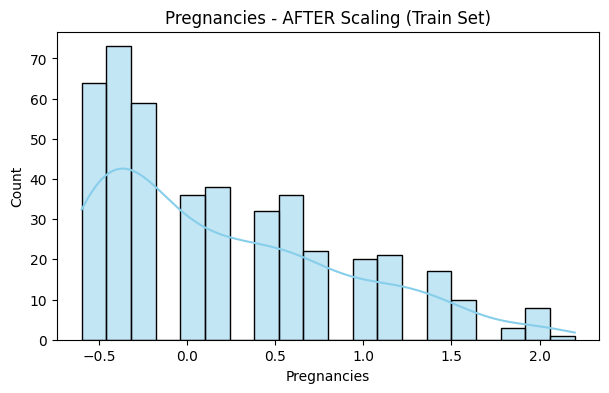

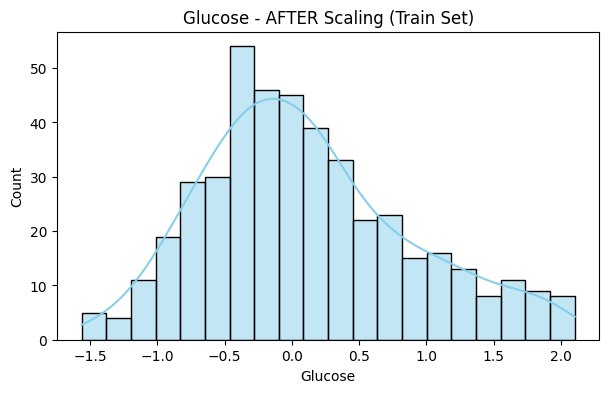

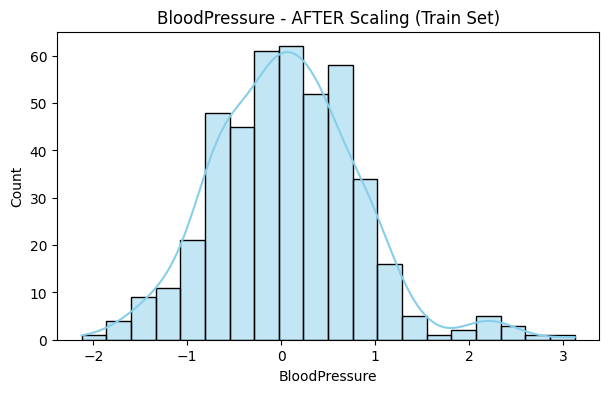

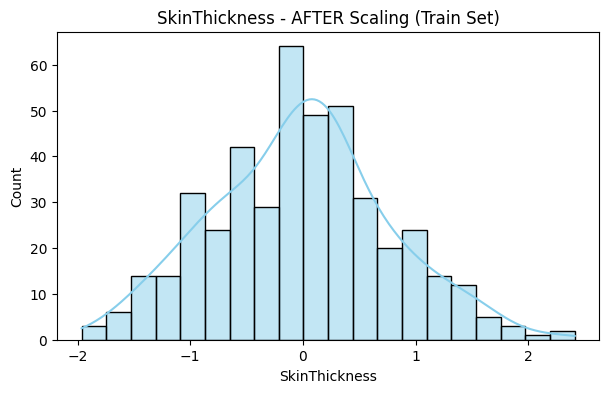

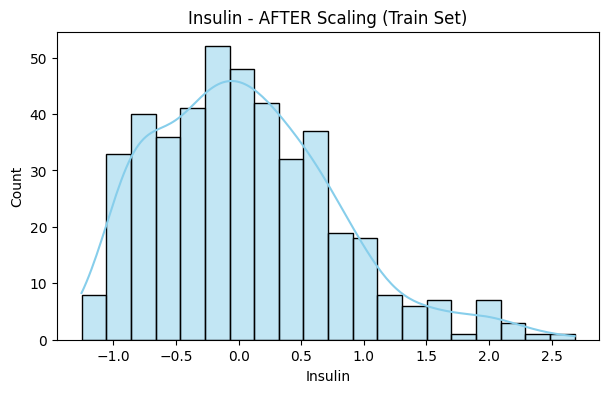

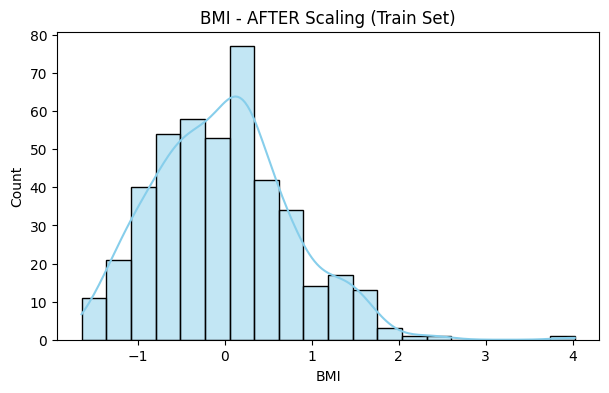

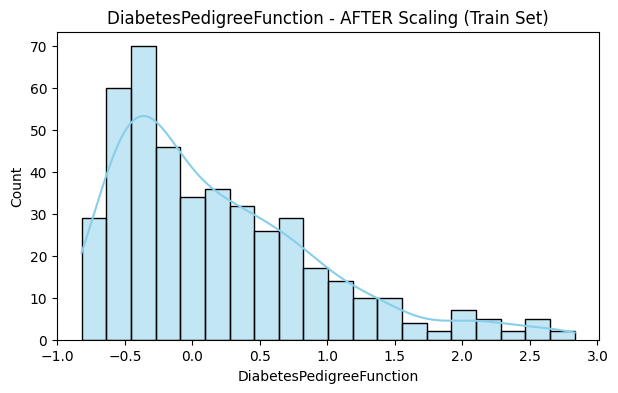

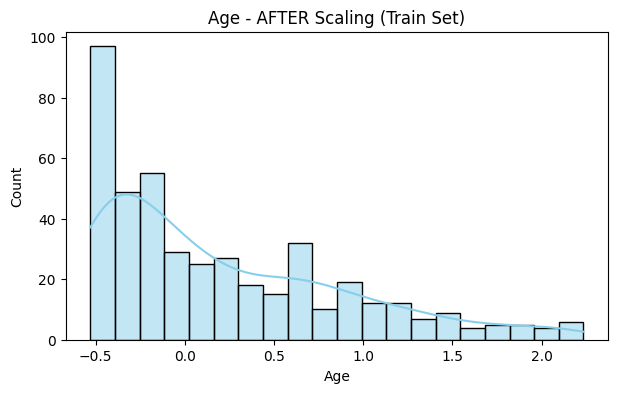

In [ ]:
plot_hist_kde(X_train_scaled, 'AFTER Scaling (Train Set)')

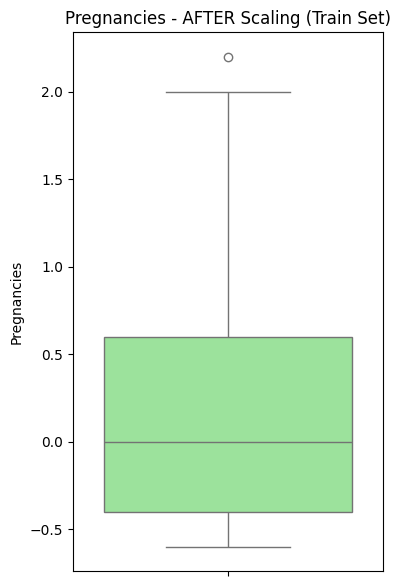

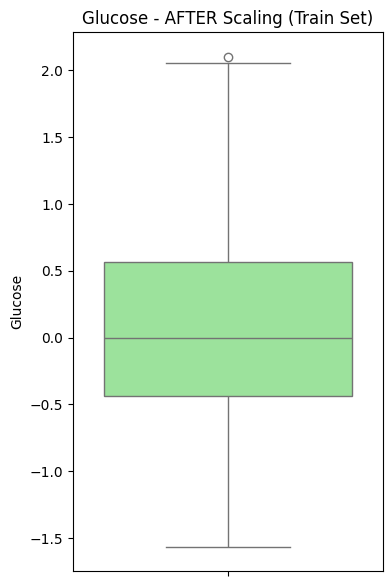

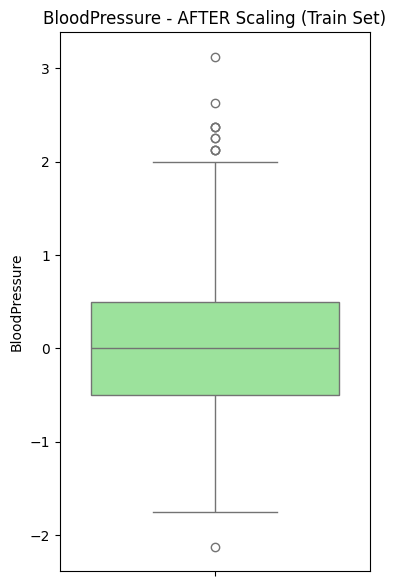

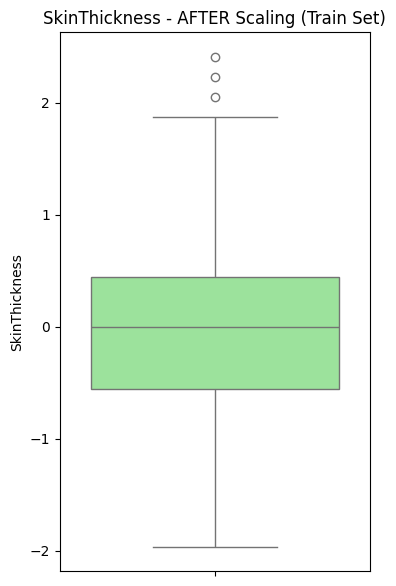

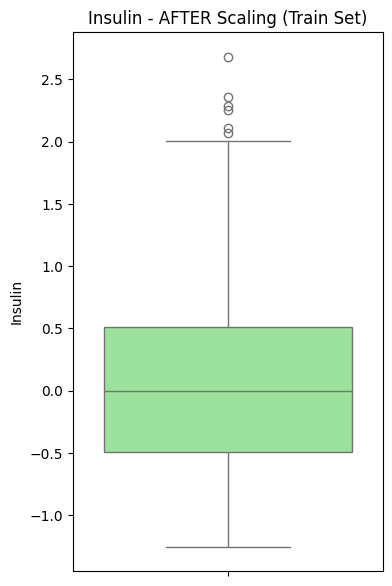

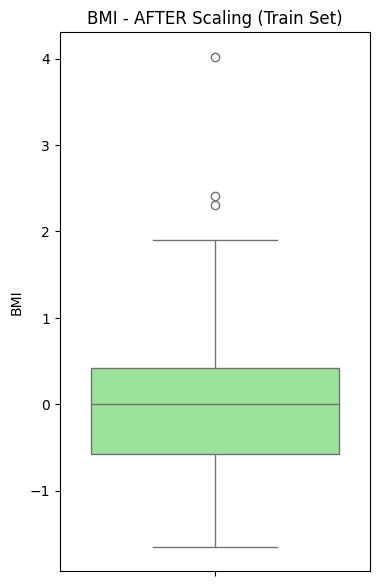

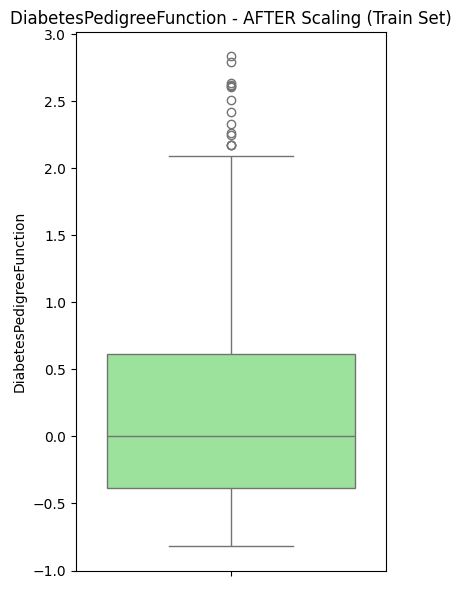

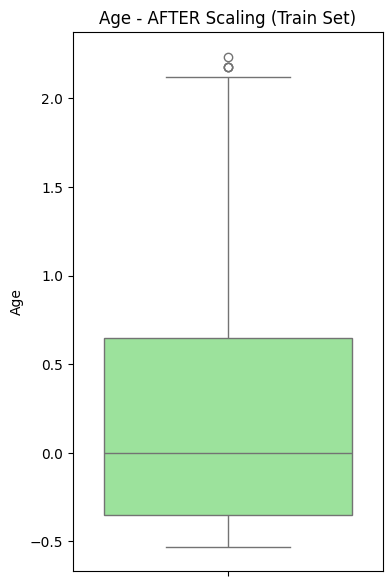

In [ ]:
plot_individual_boxplots(X_train_scaled, 'AFTER Scaling (Train Set)')

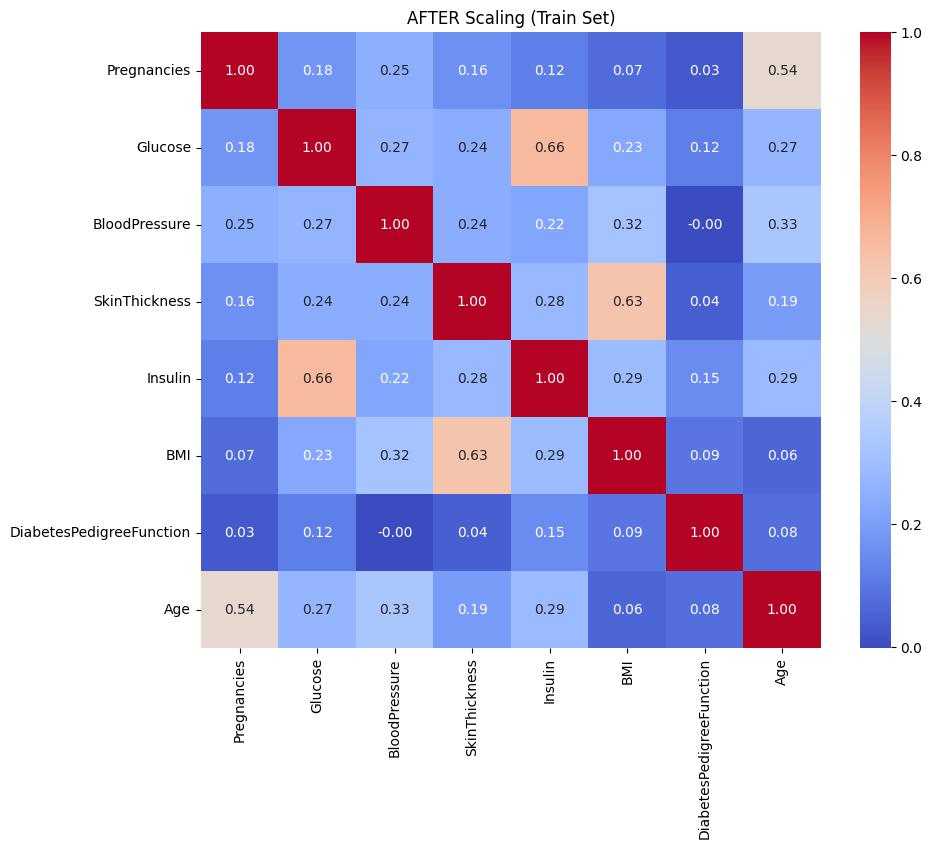

In [ ]:
# Correlation Metrix
plt.figure(figsize=(10,8))
corr_after = X_train_scaled.corr()
sns.heatmap(corr_after, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('AFTER Scaling (Train Set)')
plt.show()

In [ ]:
# Statistical summary for training set
print("Statistical summary of scaled training features:")
print(X_train_scaled.describe())

Statistical summary of scaled training features:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   440.000000  440.000000     440.000000     440.000000  440.000000   
mean      0.201818    0.106900       0.055142      -0.022159    0.049339   
std       0.689258    0.773838       0.766860       0.785054    0.728354   
min      -0.600000   -1.564103      -2.125000      -1.964286   -1.253306   
25%      -0.400000   -0.435897      -0.500000      -0.553571   -0.492370   
50%       0.000000    0.000000       0.000000       0.000000    0.000000   
75%       0.600000    0.564103       0.500000       0.446429    0.507630   
max       2.200000    2.102564       3.125000       2.410714    2.683622   

              BMI  DiabetesPedigreeFunction         Age  
count  440.000000                440.000000  440.000000  
mean    -0.018904                  0.190974    0.206390  
std      0.784140                  0.764071    0.684337  
min     -1.646377                 

In [ ]:
df_train_cleaned = X_train_no_outliers_z.copy()
df_train_cleaned['Outcome'] = y_train_no_outliers_z.reset_index(drop=True)
df_train_cleaned.to_csv('train_cleaned.csv', index=False)

# **7. Feature Engineering**

In [ ]:
def create_clinical_features(X_train_no_outliers_z):
    X = X_train_no_outliers_z.copy()

    # 1. Interaction features
    X['Glucose_BMI_Interaction'] = X['Glucose'] * X['BMI']
    X['Glucose_Genetic_Interaction'] = X['Glucose'] * X['DiabetesPedigreeFunction']

    # 2. Clinical risk scores
    X['Metabolic_Score'] = (X['Glucose']/100) + (X['BMI']/30) + (X['BloodPressure']/80)

    # 3. Clinical thresholds
    X['Obese'] = (X['BMI'] >= 30).astype(int)
    X['Hypertensive'] = (X['BloodPressure'] >= 130).astype(int)

    # 4. Polynomial features
    X['Glucose_Squared'] = X['Glucose'] ** 2

    return X

X_train_engineered = create_clinical_features(X_train_no_outliers_z)
X_val_engineered = create_clinical_features(X_val_imputed_df)
X_test_engineered = create_clinical_features(X_test_imputed_df)

In [ ]:
scaler = RobustScaler()
X_train_scaled_eng = scaler.fit_transform(X_train_engineered)
X_val_scaled_eng = scaler.transform(X_val_engineered)
X_test_scaled_eng = scaler.transform(X_test_engineered)

# Convert back to DataFrame
X_train_scaled_eng = pd.DataFrame(X_train_scaled_eng, columns=X_train_engineered.columns)
X_val_scaled_eng = pd.DataFrame(X_val_scaled_eng, columns=X_val_engineered.columns)
X_test_scaled_eng = pd.DataFrame(X_test_scaled_eng, columns=X_test_engineered.columns)

In [ ]:
# check the shapes of datasets
print(f"X_train_scaled_eng shape: {X_train_scaled_eng.shape}")
print(f"y_train shape: {y_train_no_outliers_z.shape}")
print(f"X_val_scaled_eng shape: {X_val_scaled_eng.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test_scaled_eng shape: {X_test_scaled_eng.shape}")
print(f"y_test shape: {y_test.shape}")

# Check if any samples were dropped during feature engineering
print(f"\X_train_no_outliers_z shape: {X_train_no_outliers_z.shape}")

X_train_scaled_eng shape: (440, 14)
y_train shape: (440,)
X_val_scaled_eng shape: (153, 14)
y_val shape: (153,)
X_test_scaled_eng shape: (154, 14)
y_test shape: (154,)
\X_train_no_outliers_z shape: (440, 8)


<>:10: SyntaxWarning: invalid escape sequence '\X'
<>:10: SyntaxWarning: invalid escape sequence '\X'
/tmp/ipython-input-479658813.py:10: SyntaxWarning: invalid escape sequence '\X'
  print(f"\X_train_no_outliers_z shape: {X_train_no_outliers_z.shape}")


In [ ]:
# Ensure their value are the same
print(f"X_train shape: {X_train_scaled_eng.shape}")
print(f"y_train shape: {y_train_no_outliers_z.shape}")

X_train shape: (440, 14)
y_train shape: (440,)


In [ ]:
y_train = y_train_no_outliers_z


Classification Report (with Engineered Features):
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       100
           1       0.69      0.64      0.67        53

    accuracy                           0.78       153
   macro avg       0.76      0.75      0.75       153
weighted avg       0.77      0.78      0.78       153



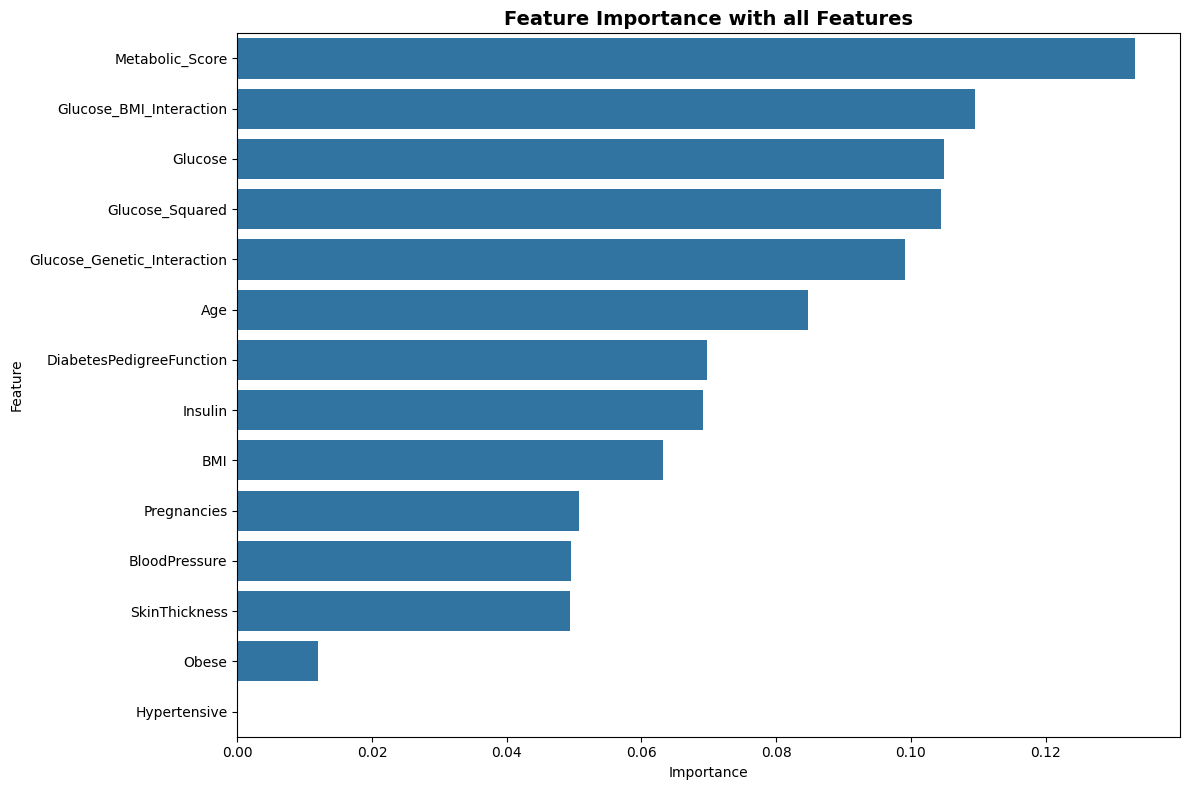


All Features Ranking:
                        Feature  Importance
10              Metabolic_Score    0.133277
8       Glucose_BMI_Interaction    0.109541
1                       Glucose    0.104937
13              Glucose_Squared    0.104526
9   Glucose_Genetic_Interaction    0.099172
7                           Age    0.084785
6      DiabetesPedigreeFunction    0.069785
4                       Insulin    0.069119
5                           BMI    0.063125
0                   Pregnancies    0.050783
2                 BloodPressure    0.049510
3                 SkinThickness    0.049457
11                        Obese    0.011984
12                 Hypertensive    0.000000

Classification Report (without Engineered Features):
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       100
           1       0.69      0.64      0.67        53

    accuracy                           0.78       153
   macro avg       0.76      0.75      0.75  

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

# 4. Train RandomForest Classifier
rf_engineered = RandomForestClassifier(n_estimators=100, random_state=42)
rf_engineered.fit(X_train_scaled_eng, y_train)

# Classification report
y_val_pred = rf_engineered.predict(X_val_scaled_eng)
print("\nClassification Report (with Engineered Features):")
print(classification_report(y_val, y_val_pred))

# 5. Feature importance with engineered features
feature_importances = rf_engineered.feature_importances_
importance_df_engineered = pd.DataFrame({'Feature': X_train_scaled_eng.columns, 'Importance': feature_importances})
importance_df_engineered = importance_df_engineered.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_engineered.head(15))
plt.title('Feature Importance with all Features', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 6. Show all features
engineered_features = [
    'Glucose_BMI_Interaction', 'Glucose_Genetic_Interaction',
    'Metabolic_Score', 'Obese', 'Hypertensive', 'Glucose_Squared',
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

print("\nAll Features Ranking:")
engineered_importance = importance_df_engineered[importance_df_engineered['Feature'].isin(engineered_features)]
print(engineered_importance)

# Classification report
y_val_pred_eng = rf_engineered.predict(X_val_scaled_eng)
print("\nClassification Report (without Engineered Features):")
print(classification_report(y_val, y_val_pred_eng))

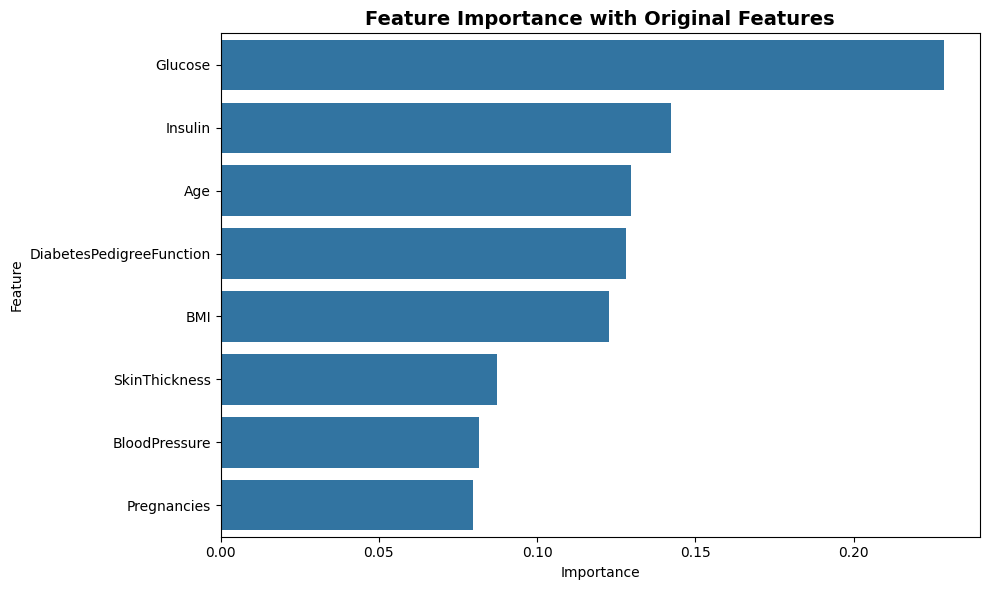


Original Features Ranking:
                    Feature  Importance
1                   Glucose    0.228479
4                   Insulin    0.142351
7                       Age    0.129611
6  DiabetesPedigreeFunction    0.128180
5                       BMI    0.122774
3             SkinThickness    0.087243
2             BloodPressure    0.081685
0               Pregnancies    0.079678

Classification Report (without Engineered Features):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.51        53

    accuracy                           0.35       153
   macro avg       0.17      0.50      0.26       153
weighted avg       0.12      0.35      0.18       153



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# 7. Compare performance with original features

# Train on original features
rf_original = RandomForestClassifier(n_estimators=100, random_state=42)
rf_original.fit(X_train_scaled, y_train)

# Feature importance with original features
feature_importances = rf_original.feature_importances_
importance_df = pd.DataFrame({'Feature': X_train_scaled.columns, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Feature Importance with Original Features', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

original_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

print("\nOriginal Features Ranking:")
ori_importance = importance_df[importance_df['Feature'].isin(original_features)]
print(ori_importance)

# Classification report
y_val_pred = rf_original.predict(X_val)
print("\nClassification Report (without Engineered Features):")
print(classification_report(y_val, y_val_pred))

In [ ]:
# Compare AUC scores
original_auc = roc_auc_score(y_test, rf_original.predict_proba(X_test_scaled)[:, 1])
engineered_auc = roc_auc_score(y_test, rf_engineered.predict_proba(X_test_scaled_eng)[:, 1])

print(f"Performance Comparison:")
print(f"\nOriginal features AUC: {original_auc:.4f}")
print(f"Engineered features AUC: {engineered_auc:.4f}")
print(f"AUC Improvement: {engineered_auc - original_auc:.4f}")

# 8. Validate on validation set
val_auc_original = roc_auc_score(y_val, rf_original.predict_proba(X_val)[:, 1])
val_auc_engineered = roc_auc_score(y_val, rf_engineered.predict_proba(X_val_scaled_eng)[:, 1])

print(f"\nValidation Performance:")
print(f"Original features Val AUC: {val_auc_original:.4f}")
print(f"Engineered features Val AUC: {val_auc_engineered:.4f}")
print(f"Val AUC Improvement: {val_auc_engineered - val_auc_original:.4f}")

# 9. Validate on test set
test_auc_original = roc_auc_score(y_test, rf_original.predict_proba(X_test_scaled)[:, 1])
test_auc_engineered = roc_auc_score(y_test, rf_engineered.predict_proba(X_test_scaled_eng)[:, 1])

print(f"\nTest Performance:")
print(f"Original features Test AUC: {test_auc_original:.4f}")
print(f"Engineered features Test AUC: {test_auc_engineered:.4f}")
print(f"Test AUC Improvement: {test_auc_engineered - test_auc_original:.4f}")

Performance Comparison:

Original features AUC: 0.7962
Engineered features AUC: 0.8008
AUC Improvement: 0.0046

Validation Performance:
Original features Val AUC: 0.3827
Engineered features Val AUC: 0.8357
Val AUC Improvement: 0.4529

Test Performance:
Original features Test AUC: 0.7962
Engineered features Test AUC: 0.8008
Test AUC Improvement: 0.0046


## Feature Reduction

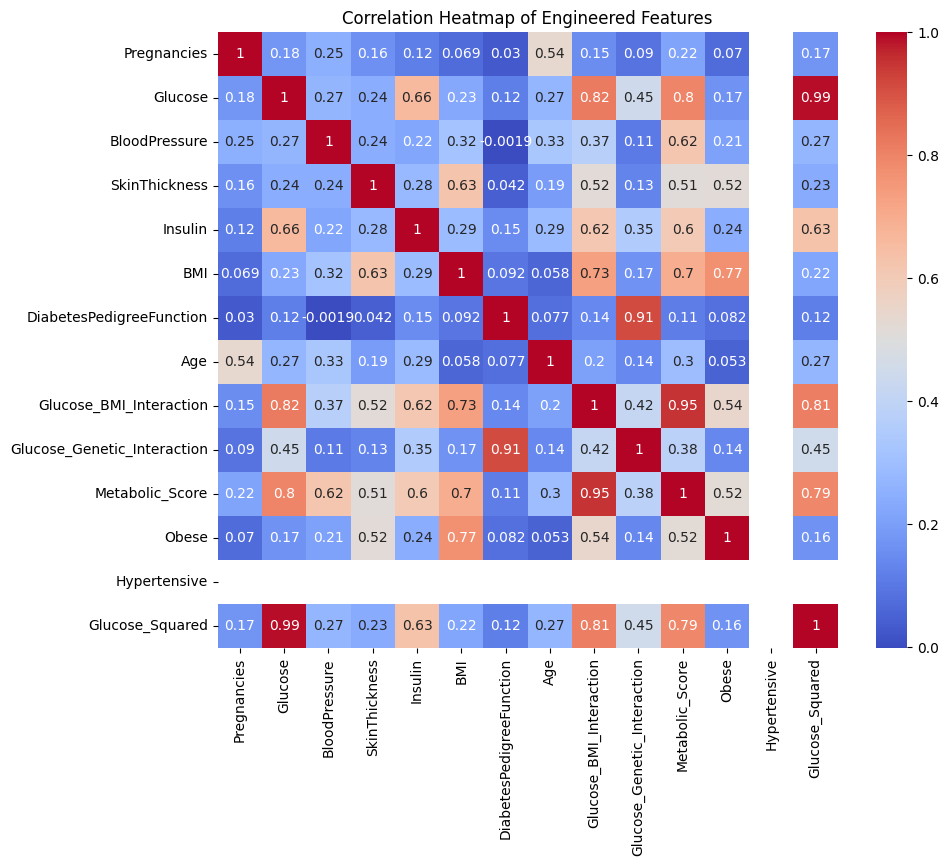

In [ ]:
# Show Correlated Target for engineered features
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(X_train_scaled_eng.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Engineered Features')
plt.show()

In [ ]:
correlation_matrix = X_train_scaled_eng.corr()

# Find high correlations
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:  # Very high correlation
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print("Highly correlated pairs (>0.9):")
for feat1, feat2, corr in high_corr_pairs:
    imp1 = importance_df_engineered[importance_df_engineered['Feature']==feat1]['Importance'].values[0]
    imp2 = importance_df_engineered[importance_df_engineered['Feature']==feat2]['Importance'].values[0]
    print(f"{feat1} vs {feat2}: {corr:.3f}")
    print(f"  Importance: {feat1}={imp1:.3f}, {feat2}={imp2:.3f}")
    print(f"  → Keep {feat1 if imp1 > imp2 else feat2}")

Highly correlated pairs (>0.9):
Glucose vs Glucose_Squared: 0.990
  Importance: Glucose=0.105, Glucose_Squared=0.105
  → Keep Glucose
DiabetesPedigreeFunction vs Glucose_Genetic_Interaction: 0.912
  Importance: DiabetesPedigreeFunction=0.070, Glucose_Genetic_Interaction=0.099
  → Keep Glucose_Genetic_Interaction
Glucose_BMI_Interaction vs Metabolic_Score: 0.949
  Importance: Glucose_BMI_Interaction=0.110, Metabolic_Score=0.133
  → Keep Metabolic_Score


In [ ]:
# Only drop the less important feature from highly correlated pairs
features_to_drop = []
for feat1, feat2, corr in high_corr_pairs:
    imp1 = importance_df_engineered[importance_df_engineered['Feature']==feat1]['Importance'].values[0]
    imp2 = importance_df_engineered[importance_df_engineered['Feature']==feat2]['Importance'].values[0]
    if imp1 < imp2:
        features_to_drop.append(feat1)
    else:
        features_to_drop.append(feat2)

# Drop Hypertensive due to very low importance
features_to_drop.append('Hypertensive')

features_to_drop = list(set(features_to_drop))  # Remove duplicates
print(f"\nDropping only: {features_to_drop}")

# Drop the features
X_train_scaled_eng = X_train_scaled_eng.drop(columns=features_to_drop, errors='ignore')
X_val_scaled_eng = X_val_scaled_eng.drop(columns=features_to_drop, errors='ignore')
X_test_scaled_eng = X_test_scaled_eng.drop(columns=features_to_drop, errors='ignore')


Dropping only: ['DiabetesPedigreeFunction', 'Hypertensive', 'Glucose_Squared', 'Glucose_BMI_Interaction']


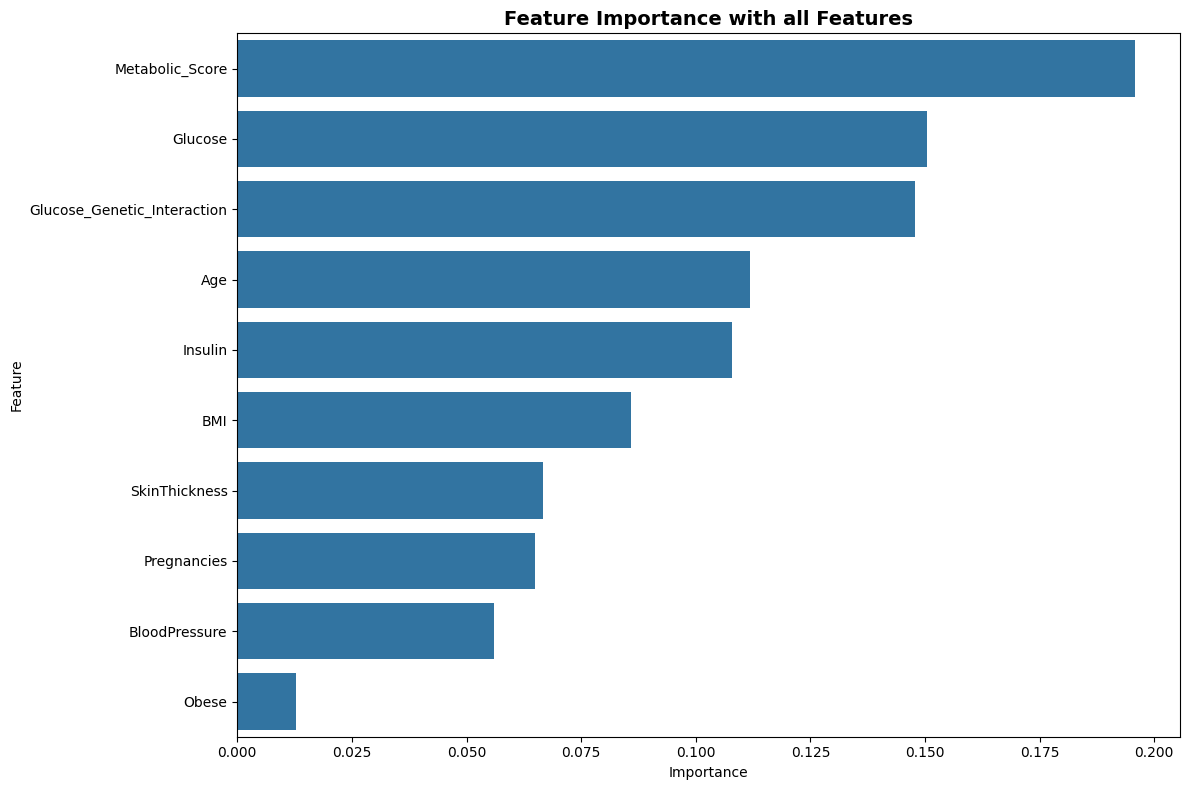

In [ ]:
# Feature Importance after dropped some features
rf_engineered = RandomForestClassifier(n_estimators=100, random_state=42)
rf_engineered.fit(X_train_scaled_eng, y_train)

feature_importances = rf_engineered.feature_importances_
importance_df_engineered = pd.DataFrame({'Feature': X_train_scaled_eng.columns, 'Importance': feature_importances})
importance_df_engineered = importance_df_engineered.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_engineered.head(15))
plt.title('Feature Importance with all Features', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

##Feature Selection

### Top-N Selection

In [ ]:
# Select top features based on importance
top_features = importance_df_engineered.head(9)['Feature'].tolist()
X_train_selected = X_train_scaled_eng[top_features]
X_val_selected = X_val_scaled_eng[top_features]
X_test_selected = X_test_scaled_eng[top_features]

print(f"Selected features shape: {X_train_selected.shape}")
print("Selected features:", top_features)

Selected features shape: (440, 9)
Selected features: ['Metabolic_Score', 'Glucose', 'Glucose_Genetic_Interaction', 'Age', 'Insulin', 'BMI', 'SkinThickness', 'Pregnancies', 'BloodPressure']


In [ ]:
# Train Random Forest with selected features
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selected.fit(X_train_selected, y_train)

# Get probabilities for ALL features
y_val_proba_all = rf_engineered.predict_proba(X_val_scaled_eng)[:, 1]
y_test_proba_all = rf_engineered.predict_proba(X_test_scaled_eng)[:, 1]

# Evaluate on validation set
y_val_pred_selected = rf_selected.predict(X_val_selected)
y_val_proba_selected = rf_selected.predict_proba(X_val_selected)[:, 1]

print("\nSELECTED FEATURES - Validation Performance:")
print(classification_report(y_val, y_val_pred_selected))
print(f"Validation AUC: {roc_auc_score(y_val, y_val_proba_selected):.4f}")

# Evaluate on test set
y_test_pred_selected = rf_selected.predict(X_test_selected)
y_test_proba_selected = rf_selected.predict_proba(X_test_selected)[:, 1]

print("\nSELECTED FEATURES - Test Performance:")
print(classification_report(y_test, y_test_pred_selected))
print(f"Test AUC: {roc_auc_score(y_test, y_test_proba_selected):.4f}")


SELECTED FEATURES - Validation Performance:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.62      0.67        53

    accuracy                           0.78       153
   macro avg       0.77      0.75      0.75       153
weighted avg       0.78      0.78      0.78       153

Validation AUC: 0.8260

SELECTED FEATURES - Test Performance:
              precision    recall  f1-score   support

           0       0.75      0.85      0.79       100
           1       0.62      0.46      0.53        54

    accuracy                           0.71       154
   macro avg       0.69      0.66      0.66       154
weighted avg       0.70      0.71      0.70       154

Test AUC: 0.8004


In [ ]:
# Compare with all features
print("PERFORMANCE COMPARISON: ")
print(f"All Features ({X_train_scaled_eng.shape[1]} features):")
print(f"  Validation AUC: {roc_auc_score(y_val, y_val_proba_all):.4f}")
print(f"  Test AUC: {roc_auc_score(y_test, y_test_proba_all):.4f}")

print(f"\nSelected Features ({len(top_features)} features):")
print(f"  Validation AUC: {roc_auc_score(y_val, y_val_proba_selected):.4f}")
print(f"  Test AUC: {roc_auc_score(y_test, y_test_proba_selected):.4f}")

# Performance drop
print(f"\nPerformance Drop:")
print(f"  Validation AUC Drop: {(roc_auc_score(y_val, y_val_proba_all) - roc_auc_score(y_val, y_val_proba_selected)):.4f}")
print(f"  Test AUC Drop: {(roc_auc_score(y_test, y_test_proba_all) - roc_auc_score(y_test, y_test_proba_selected)):.4f}")


# Performance:
# 6 features  : -0.0050 ---> drop too many (Rejected)
# 9 features  : -0.0049

# Thus, Feature Selection will be ACCEPTED !

PERFORMANCE COMPARISON: 
All Features (10 features):
  Validation AUC: 0.8287
  Test AUC: 0.8053

Selected Features (9 features):
  Validation AUC: 0.8260
  Test AUC: 0.8004

Performance Drop:
  Validation AUC Drop: 0.0026
  Test AUC Drop: 0.0049


# **9. Sampling**

In [ ]:
from imblearn.pipeline import make_pipeline
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks

smt = SMOTETomek(random_state=42, sampling_strategy='auto')

X_train_resampled, y_train_resampled = smt.fit_resample(X_train_selected, y_train)

In [ ]:
from collections import Counter

# Check original distribution
print("Original distribution:", Counter(y_train))

# After SMOTETomek
print("\nAfter SMOTETomek:", Counter(y_train_resampled))
print(y_train_resampled.value_counts(normalize=True)) # get the proportion

Original distribution: Counter({0: 289, 1: 151})

After SMOTETomek: Counter({0: 276, 1: 276})
Outcome
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
# Convert to Series for plotting
y_train = pd.Series(y_train)
y_train_resampled = pd.Series(y_train_resampled)

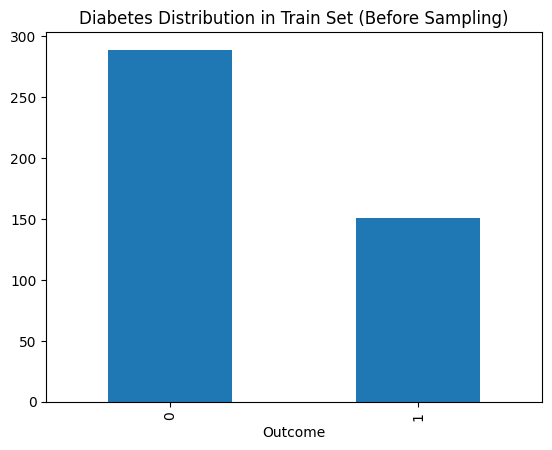

In [ ]:
# Bar Chart (Before)
y_train.value_counts().plot(kind='bar', title='Diabetes Distribution in Train Set (Before Sampling)')
plt.show()

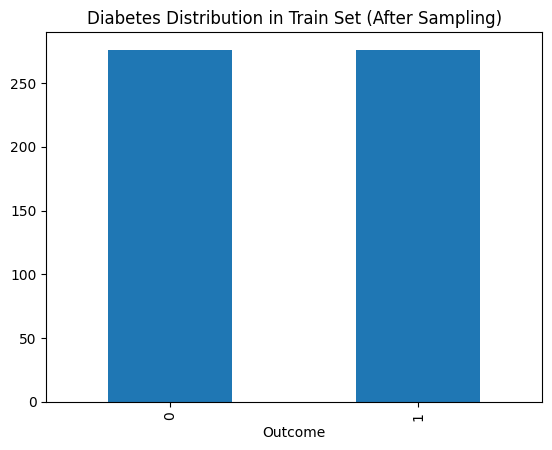

In [ ]:
# Bar Chart (After)
y_train_resampled.value_counts().plot(kind='bar', title='Diabetes Distribution in Train Set (After Sampling)')
plt.show()

# **10. Modeling**

In [ ]:
# plot roc curve
from sklearn.metrics import roc_curve

def plot_roc_curve(y_test, y_pred):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # diagonal line representing random guessing
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

In [ ]:
LR_model = LogisticRegression(max_iter=10000)
LR_model.fit(X_train_resampled, y_train_resampled)
y_pred = LR_model.predict(X_test_selected)
y_pred_proba = LR_model.predict_proba(X_test_selected)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.81      0.78      0.80       100
           1       0.62      0.67      0.64        54

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.74      0.74       154

ROC AUC Score:  0.8011111111111111


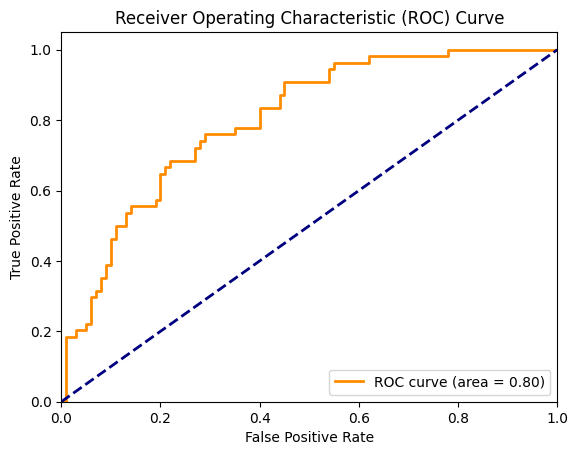

In [ ]:
plot_roc_curve(y_test, y_pred_proba)

In [ ]:
# param_distribution for RandomizedSearchCV
param_grid = {
    "penalty": ["l2"],
    "solver": ["lbfgs", "newton-cg", "saga"],
    "multi_class": ["ovr", "multinomial"],
    "C": np.logspace(-3, 2, 20),
    "class_weight": [None, "balanced"],
    "fit_intercept": [True, False],
}

# set up the random search with stratified cross-validation on the training data
grid = RandomizedSearchCV(
    estimator=LR_model,
    scoring="roc_auc",
    param_distributions=param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=1),
    refit=True,
    n_iter=50,
    verbose=3,
    n_jobs=-1,
    random_state=1
)
grid.fit(X_train_resampled, y_train_resampled)

print(f'Best score: {grid.best_score_} with param: {grid.best_params_}')

# logistic regression with fine tuning
LR_model2 = grid.best_estimator_
y_pred_proba = LR_model2.predict_proba(X_test_selected)[:, 1]
y_pred = LR_model2.predict(X_test_selected)
#y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_pred_proba))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best score: 0.8707048406139316 with param: {'solver': 'lbfgs', 'penalty': 'l2', 'multi_class': 'ovr', 'fit_intercept': True, 'class_weight': None, 'C': np.float64(0.06951927961775606)}
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       100
           1       0.61      0.65      0.63        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.73      0.74       154

ROC AUC Score:  0.7966666666666666


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


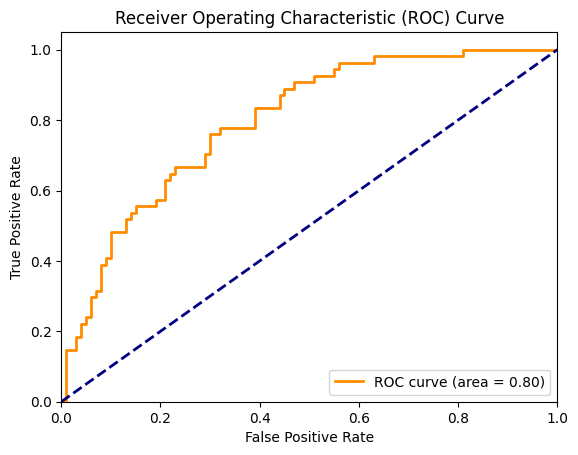

In [ ]:
# roc curve for logistic regression with fine tuning
plot_roc_curve(y_test, y_pred_proba)

## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import  roc_auc_score
from sklearn.metrics import classification_report

In [ ]:
DT_model = DecisionTreeClassifier()
DT_model.fit(X_train_resampled, y_train_resampled)
y_pred = DT_model.predict(X_test_selected)
y_pred_proba = DT_model.predict_proba(X_test_selected)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.79      0.78      0.78       100
           1       0.60      0.61      0.61        54

    accuracy                           0.72       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.72      0.72       154

ROC AUC Score:  0.6955555555555556


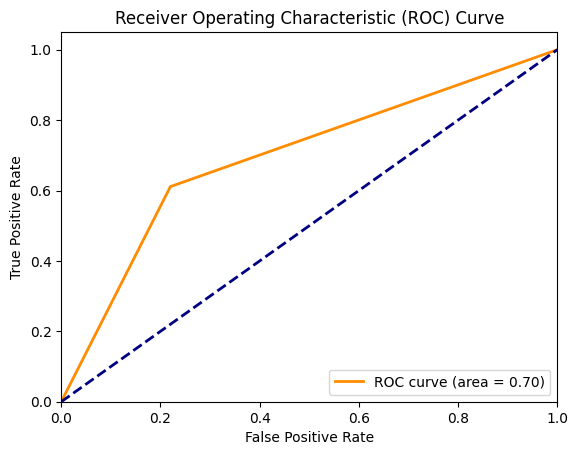

In [ ]:
plot_roc_curve(y_test, y_pred_proba)

In [ ]:
# param_distribution for RandomizedSearchCV
criterion = ['gini', 'entropy', 'log_loss']
splitter = ['best', 'random']
max_depth = [i for i in range(1, 41, 5)]
min_samples_split = [i for i in range(2, 21, 2)]
min_samples_leaf = [i for i in range(1, 21, 2)]

param_grid = {
    "criterion": criterion,
    "max_depth": max_depth,
    "min_samples_split": min_samples_split,
    "splitter": splitter,
    "min_samples_leaf": min_samples_leaf
}

# set up the random search with stratified cross-validation on the training data
grid = RandomizedSearchCV(
    estimator=DT_model,
    param_distributions=param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(5, shuffle=True, random_state=1),
    n_iter=10,
    n_jobs=-1,
    random_state=42,
    verbose=2
)
grid.fit(X_train_resampled, y_train_resampled)

print(f'Best score: {grid.best_score_} with param: {grid.best_params_}')

# decision tree with fine tuning
DT_model2 = grid.best_estimator_
y_pred_proba = DT_model2.predict_proba(X_test_selected)[:, 1]
y_pred = DT_model2.predict(X_test_selected)
#y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_pred_proba))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best score: 0.8643229043683588 with param: {'splitter': 'best', 'min_samples_split': 14, 'min_samples_leaf': 17, 'max_depth': 11, 'criterion': 'log_loss'}
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       100
           1       0.61      0.70      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154

ROC AUC Score:  0.7573148148148148


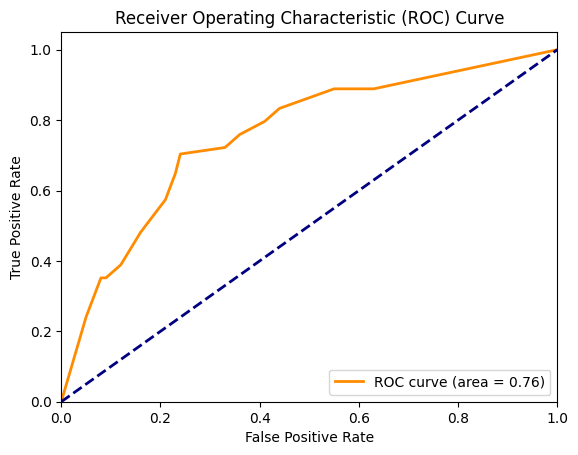

In [ ]:
# roc curve for decision tree with fine tuning
plot_roc_curve(y_test, y_pred_proba)

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import  roc_auc_score
from sklearn.metrics import classification_report

In [ ]:
RF_model = RandomForestClassifier(random_state=13, criterion='entropy', class_weight='balanced', n_estimators=100)
RF_model.fit(X_train_resampled, y_train_resampled)
y_pred = RF_model.predict(X_test_selected)
y_pred_proba = RF_model.predict_proba(X_test_selected)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.78      0.82      0.80       100
           1       0.63      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154

ROC AUC Score:  0.8114814814814816


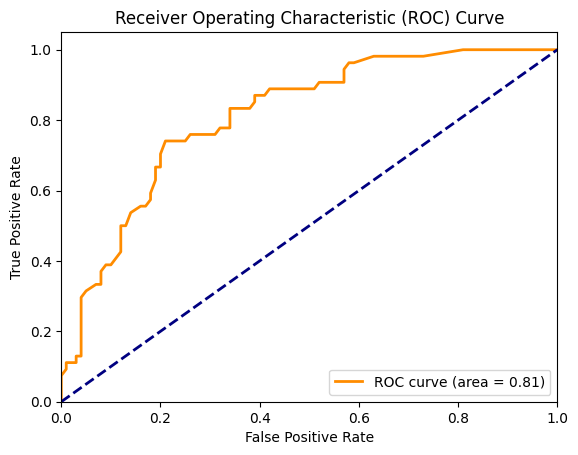

In [ ]:
plot_roc_curve(y_test, y_pred_proba)

In [ ]:
# param_distribution for RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],  # no of trees in forest
    'max_depth': [5, 10, 15],  # max depth of tree
    'min_samples_split': [2, 5, 10],  # min no of samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # min no of samples required at each leaf node
}

# set up the random search with stratified cross-validation on the training data
grid = RandomizedSearchCV(
    estimator=RF_model,
    param_distributions=param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_iter=10,
    n_jobs=1,
    random_state=42,
    verbose=2
)
grid.fit(X_train_resampled, y_train_resampled)

print("Best parameters found: ", grid.best_params_)
print("Best score found: ", grid.best_score_)

RF_model2 = grid.best_estimator_
y_pred_proba = RF_model2.predict_proba(X_test_selected)[:, 1]
y_pred = RF_model2.predict(X_test_selected)
#y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_pred_proba))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=5, min_samples_

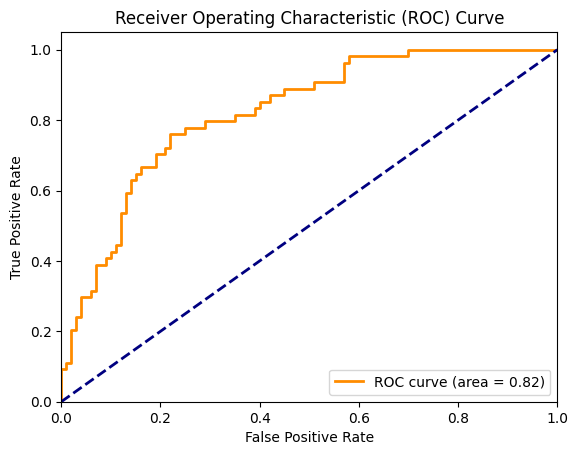

In [ ]:
# roc curve for random forest with fine tuning
plot_roc_curve(y_test, y_pred_proba)

## Neural Network

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping
from keras.metrics import AUC
from keras.metrics import Recall
from keras.utils import to_categorical
from sklearn.metrics import  roc_auc_score
from sklearn.metrics import classification_report

In [ ]:
NN_model = MLPClassifier(max_iter=1000)
NN_model.fit(X_train_resampled, y_train_resampled)
y_pred = NN_model.predict(X_test_selected)
y_pred_proba = NN_model.predict_proba(X_test_selected)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.75      0.76      0.76       100
           1       0.55      0.54      0.54        54

    accuracy                           0.68       154
   macro avg       0.65      0.65      0.65       154
weighted avg       0.68      0.68      0.68       154

ROC AUC Score:  0.7514814814814814


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


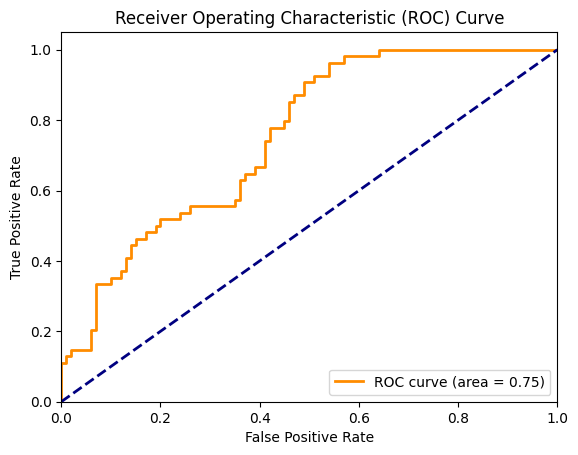

In [ ]:
plot_roc_curve(y_test, y_pred_proba)

In [ ]:
class_weights = compute_class_weight(class_weight="balanced",
                                     classes=np.unique(y_train_resampled),
                                     y=y_train_resampled)

class_weights = dict(enumerate(class_weights))

NN_model2 = Sequential()
NN_model2.add(Dense(64, activation='relu', input_dim=len(top_features), kernel_initializer='he_uniform'))
NN_model2.add(Dense(32, activation='relu'))
NN_model2.add(Dense(1, activation='sigmoid'))   # binary output

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

NN_model2.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy', AUC(), Recall()])

NN_model2.fit(X_train_resampled, y_train_resampled,
          epochs=30, batch_size=100,
          class_weight=class_weights,
          validation_data=(X_val_selected, y_val),
          callbacks=[early_stopping])

NN_model2.summary()

y_pred = NN_model2.predict(X_test_selected)
y_pred_classes = (y_pred > 0.5).astype("int32")
print(classification_report(y_test, y_pred_classes))
print("ROC AUC Score: ", roc_auc_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.4311 - auc: 0.4040 - loss: 0.8108 - recall: 0.2505 - val_accuracy: 0.6732 - val_auc: 0.6977 - val_loss: 0.6300 - val_recall: 0.6038
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6426 - auc: 0.7096 - loss: 0.6230 - recall: 0.5640 - val_accuracy: 0.7320 - val_auc: 0.8080 - val_loss: 0.5455 - val_recall: 0.6792
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7720 - auc: 0.8353 - loss: 0.5261 - recall: 0.8222 - val_accuracy: 0.7516 - val_auc: 0.8400 - val_loss: 0.5218 - val_recall: 0.7547
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7745 - auc: 0.8609 - loss: 0.4793 - recall: 0.8329 - val_accuracy: 0.7712 - val_auc: 0.8466 - val_loss: 0.5108 - val_recall: 0.7547
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7908 - auc: 0.8750 - loss: 0.4530 - recall: 0.8418 - val_accuracy: 0.7582 - val_auc: 0.8448 - val_loss: 0.4982 - val_recall: 0.7358
Epoch 6/30
6/6 ━━━━━━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,261 (32.27 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,508 (21.52 KB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       100
           1       0.63      0.69      0.65        54

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

ROC AUC Score:  0.8051851851851851


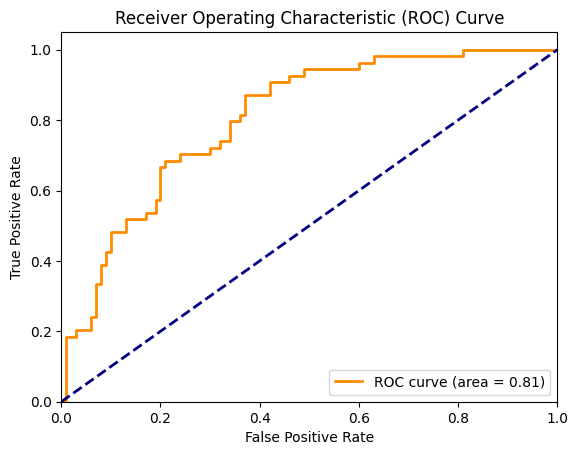

In [ ]:
# roc curve for NN from keras
plot_roc_curve(y_test, y_pred)

##K-Nearest Neighbors

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train_resampled, y_train_resampled)
y_pred = knn.predict(X_test_selected)
y_proba = knn.predict_proba(X_test_selected)[:,1]
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.78      0.68      0.73       100
           1       0.52      0.65      0.58        54

    accuracy                           0.67       154
   macro avg       0.65      0.66      0.65       154
weighted avg       0.69      0.67      0.68       154

ROC-AUC: 0.7169


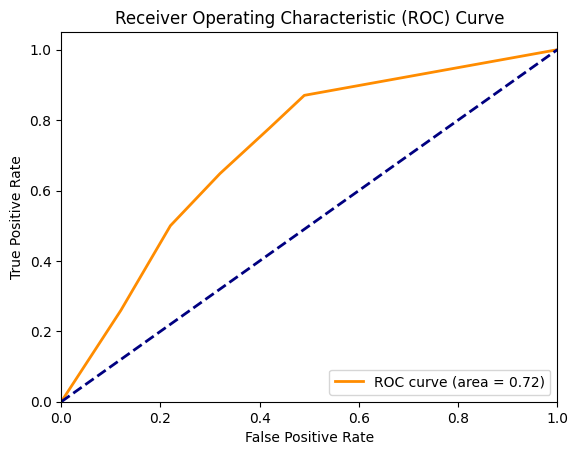

In [ ]:
plot_roc_curve(y_test, y_proba)

In [ ]:
# Hyperparameter tuning for KNN
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # 1=manhattan, 2=euclidean (when metric='minkowski')
}

In [ ]:
knn_model = KNeighborsClassifier()
knn_search = GridSearchCV(
    knn_model,
    param_grid_knn,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

knn_search.fit(X_train_resampled, y_train_resampled)
print(f"Best parameters: {knn_search.best_params_}")
print(f"Best CV score: {knn_search.best_score_:.4f}")

Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Best CV score: 0.9182


In [ ]:
# Evaluate
knn_best = knn_search.best_estimator_
y_pred = knn_best.predict(X_test_selected)
y_proba = knn_best.predict_proba(X_test_selected)[:, 1]

print("Test Set Performance:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Test Set Performance:
              precision    recall  f1-score   support

           0       0.83      0.68      0.75       100
           1       0.56      0.74      0.63        54

    accuracy                           0.70       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.73      0.70      0.71       154

ROC-AUC: 0.7572


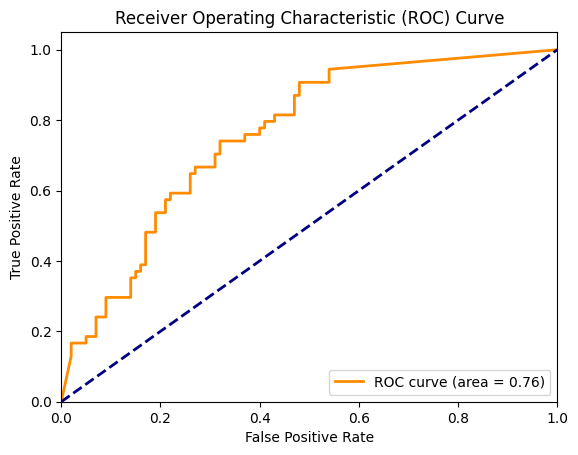

In [ ]:
plot_roc_curve(y_test, y_proba)

##Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train_resampled, y_train_resampled);

In [ ]:
# Evaluate
y_pred = nb_model.predict(X_test_selected)
y_proba = nb_model.predict_proba(X_test_selected)[:, 1]

In [ ]:
print("Test Set Performance:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Test Set Performance:
              precision    recall  f1-score   support

           0       0.77      0.74      0.76       100
           1       0.55      0.59      0.57        54

    accuracy                           0.69       154
   macro avg       0.66      0.67      0.66       154
weighted avg       0.69      0.69      0.69       154

ROC-AUC: 0.7876


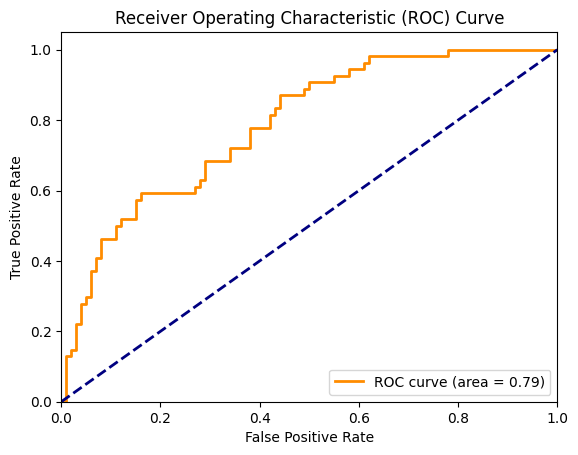

In [ ]:
plot_roc_curve(y_test, y_proba)

##Stacking Classifier

In [ ]:
from sklearn.ensemble import StackingClassifier

In [ ]:
# Define base models
base_models = [
    ('lr', LR_model2),
    ('rf', RF_model2),
    ('knn', KNeighborsClassifier(n_neighbors=9)),
    ('nb', GaussianNB()),
    ('dt', DT_model2)
]

In [ ]:
# Meta-learner (model that combines base models)
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

# Create stacking classifier
stacking_classifier = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,  # Number of folds for cross-validation
    stack_method='predict_proba',  # Use probabilities
    n_jobs=-1
)

stacking_classifier.fit(X_train_resampled, y_train_resampled);

In [ ]:
# Evaluate
y_pred = stacking_classifier.predict(X_test_selected)
y_proba = stacking_classifier.predict_proba(X_test_selected)[:, 1]

print("Test Set Performance:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Test Set Performance:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       100
           1       0.67      0.63      0.65        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154

ROC-AUC: 0.8159


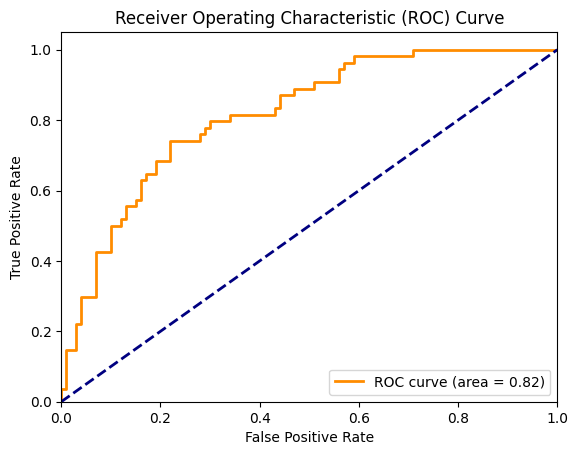

In [ ]:
plot_roc_curve(y_test, y_proba)

# **Summary of Tuned Model**

In [ ]:
def create_performance_table(input_data):
    if isinstance(input_data[0], dict):
        df = pd.DataFrame(input_data)
    else:
        columns = ['Model', 'Accuracy','AUC']
        df = pd.DataFrame(input_data, columns=columns)

    return df

# after tuned
data_dict_format = [
    {'Model': 'Logistic Regression', 'Accuracy': 0.73, 'AUC': 0.7967},
    {'Model': 'Decision Tree', 'Accuracy': 0.74, 'AUC': 0.7579},
    {'Model': 'Random Forest', 'Accuracy': 0.77, 'AUC': 0.8224},
    {'Model': 'Neural Network', 'Accuracy': 0.71, 'AUC': 0.7885},
    {'Model': 'K-Nearest Neighbors', 'Accuracy': 0.70, 'AUC': 0.7572},
    {'Model': 'Naive Bayes', 'Accuracy': 0.69, 'AUC': 0.7876},
    {'Model': 'Stacking Classifier', 'Accuracy': 0.78, 'AUC': 0.8117}
]

performance_df = create_performance_table(data_dict_format)
performance_df

,Model,Accuracy,AUC
0,Logistic Regression,0.73,0.7967
1,Decision Tree,0.74,0.7579
2,Random Forest,0.77,0.8224
3,Neural Network,0.71,0.7885
4,K-Nearest Neighbors,0.70,0.7572
5,Naive Bayes,0.69,0.7876
6,Stacking Classifier,0.78,0.8117


# **11. Deployment**

In [ ]:
deployment_components = {
    'imputer': imputer,
    'scaler': scaler,
    'model': RF_model2,
    'selected_features': top_features,
    'cleaning_cols': cols_with_fake_missing
}

In [ ]:
import joblib

joblib.dump(deployment_components, 'diabetes_deployment_pipeline.joblib')
print("All components saved")

All components saved


In [ ]:
#Load data
df_test = pd.read_csv('diabetes2.csv')

In [ ]:
# Remove Outcome column if it exists (we want to predict this)
if 'Outcome' in df_test.columns:
    df_test = df_test.drop('Outcome', axis=1)

In [ ]:
print(f"Test data shape: {df_test.shape}")
print("Test data preview:")
print(df_test.head())

Test data shape: (10, 8)
Test data preview:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6       93             50             30       64  28.7   
1            4      109             64             44       99  34.8   
2           14      100             78             25      184  36.6   
3            3       82             70              0        0  21.1   
4            7      195             70             33      145  25.1   

   DiabetesPedigreeFunction  Age  
0                     0.356   23  
1                     0.905   26  
2                     0.412   46  
3                     0.389   25  
4                     0.163   55  


In [ ]:
#Clean data
df_test_clean = df_test.copy()
# Remove duplicates
df_test_clean = df_test_clean.drop_duplicates().reset_index(drop=True)

In [ ]:
# Replace zeros with NaN (using same rule from training)
for col in cols_with_fake_missing:
    if col in df_test_clean.columns:
        num_zeros = (df_test_clean[col] == 0).sum()
        df_test_clean[col] = df_test_clean[col].replace(0, np.nan)
        print(f"   {col}: Converted {num_zeros} zeros to NaN")

   Glucose: Converted 0 zeros to NaN
   BloodPressure: Converted 1 zeros to NaN
   SkinThickness: Converted 4 zeros to NaN
   Insulin: Converted 5 zeros to NaN
   BMI: Converted 0 zeros to NaN


In [ ]:
print("Imputing missing values")
df_test_imputed = imputer.transform(df_test_clean)
df_test_imputed = pd.DataFrame(df_test_imputed, columns=df_test_clean.columns)
print(f"Missing values after imputation: {df_test_imputed.isnull().sum().sum()}")

Imputing missing values
Missing values after imputation: 0


In [ ]:
print("Creating engineered features")
df_test_engineered = df_test_imputed.copy()

Creating engineered features


In [ ]:
# Create all the same engineered features as training
df_test_engineered['Glucose_BMI_Interaction'] = df_test_engineered['Glucose'] * df_test_engineered['BMI']
df_test_engineered['Glucose_Genetic_Interaction'] = df_test_engineered['Glucose'] * df_test_engineered['DiabetesPedigreeFunction']
df_test_engineered['Metabolic_Score'] = (df_test_engineered['Glucose']/100) + (df_test_engineered['BMI']/30) + (df_test_engineered['BloodPressure']/80)
df_test_engineered['Obese'] = (df_test_engineered['BMI'] >= 30).astype(int)
df_test_engineered['Hypertensive'] = (df_test_engineered['BloodPressure'] >= 130).astype(int)
df_test_engineered['Glucose_Squared'] = df_test_engineered['Glucose'] ** 2

In [ ]:
print("Scaling features")
df_test_scaled = scaler.transform(df_test_engineered)
df_test_scaled = pd.DataFrame(df_test_scaled, columns=df_test_engineered.columns)

Scaling features


In [ ]:
print("Select features")
df_test_selected = df_test_scaled[top_features]
print(f"Selected same {len(top_features)} features as training")
print(f"Features: {top_features}")

Select features
Selected same 9 features as training
Features: ['Metabolic_Score', 'Glucose', 'Glucose_Genetic_Interaction', 'Age', 'Insulin', 'BMI', 'SkinThickness', 'Pregnancies', 'BloodPressure']


In [ ]:
# Use best trained model
predictions = RF_model2.predict(df_test_selected)
probabilities = RF_model2.predict_proba(df_test_selected)[:, 1]

In [ ]:
#Final result
# Create results dataframe
results_df = df_test.copy()
results_df['Prediction'] = ['DIABETIC' if pred == 1 else 'NON-DIABETIC' for pred in predictions]
results_df['Probability'] = probabilities
results_df['Risk_Level'] = ['HIGH' if p > 0.6 else 'MEDIUM' if p > 0.4 else 'LOW' for p in probabilities]

# Display all results
print("Detailed Results:")
print(results_df[['Glucose', 'BMI', 'Prediction', 'Probability', 'Risk_Level']].round(3))

print(f"SUMMARY:")
print(f"Total patients: {len(results_df)}")
print(f"Predicted diabetic: {sum(predictions)} ({sum(predictions)/len(predictions)*100:.1f}%)")
print(f"Predicted non-diabetic: {len(predictions) - sum(predictions)} ({(len(predictions) - sum(predictions))/len(predictions)*100:.1f}%)")
print(f"Average probability: {probabilities.mean():.1%}")
print(f"Probability range: {probabilities.min():.1%} to {probabilities.max():.1%}")

Detailed Results:
   Glucose   BMI    Prediction  Probability Risk_Level
0       93  28.7  NON-DIABETIC        0.010        LOW
1      109  34.8      DIABETIC        0.537     MEDIUM
2      100  36.6      DIABETIC        0.514     MEDIUM
3       82  21.1  NON-DIABETIC        0.000        LOW
4      195  25.1      DIABETIC        0.693       HIGH
5      173  36.8      DIABETIC        0.883       HIGH
6      127  34.5  NON-DIABETIC        0.448     MEDIUM
7      108  32.4      DIABETIC        0.911       HIGH
8      131  31.6      DIABETIC        0.528     MEDIUM
9       87  28.9  NON-DIABETIC        0.010        LOW
SUMMARY:
Total patients: 10
Predicted diabetic: 6 (60.0%)
Predicted non-diabetic: 4 (40.0%)
Average probability: 45.3%
Probability range: 0.0% to 91.1%


In [ ]:
df_test["Prediction"] = predictions
df_test["Probability"] = probabilities

print(df_test)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6       93             50             30       64  28.7   
1            4      109             64             44       99  34.8   
2           14      100             78             25      184  36.6   
3            3       82             70              0        0  21.1   
4            7      195             70             33      145  25.1   
5            1      173             74              0        0  36.8   
6            4      127             88             11      155  34.5   
7           10      108             66              0        0  32.4   
8            0      131             88              0        0  31.6   
9            2       87              0             23        0  28.9   

   DiabetesPedigreeFunction  Age  Prediction  Probability  
0                     0.356   23           0     0.010000  
1                     0.905   26           1     0.537346  
2                     0.412